# 动态规划专题：从状态含义推导解法

复习时先问：**走到当前这一步，为了继续求解，必须留下哪些历史信息？** 六个模块分别整理常见的状态与依赖结构；同一道题可以从多个角度理解。

## 第 0 章 · DP 方法论

### 0.1 为什么可以把历史压缩成状态

以爬楼梯为例，到第 4 阶的走法可以不同，但从这里继续往上走，允许的下一步都是迈 1 阶或 2 阶。后续不需要知道之前每一步怎么走，只需要知道当前位置；求方案数时，把到达这个位置的走法数汇总即可。

换成股票问题，仅知道“第几天”就不够：持股时可以卖出，不持股时才可以买入。如果还有冷冻期、交易次数限制，也要检查现有信息是否足以判断下一步是否合法。

**状态足够的判断：归入同一状态的历史，应能用相同的信息判断后续选择及其贡献。** 若还必须翻查具体历史，通常说明状态漏了条件，或需要换一种定义。

| 要求的结果 | 怎样汇总同一状态的候选来源 | 起点的常见含义 |
|---|---|---|
| 最大值／最小值 | 在可比较的候选结果中取 `max`／`min` | 尚无收益或尚无代价；不可达状态按需要设为极值 |
| 方案数 | 将互不重叠的来源方案数相加 | 什么都没做也是一种起始方案，常设为 1 |
| 是否可达 | 只要有一条合法来路就为真 | 起点自身可达，常设为 `True` |

求最优值时，还要确认保留的结果足以支持后续转移。例如最大子数组和能只保留同一结尾的最大和，因为加上同一个数不会改变大小关系；乘积遇到负数会翻转大小，因此还要保留最小乘积。计数则要检查分类是否重复，否则相加会重复计算。

本专题的递推依赖都可以按进度排列：较早位置、较少物品、较短前缀或较小区间先计算。把相同子问题的结果保存下来，避免反复求解，就是这里使用 DP 的共同方式。自底向上填表与自顶向下记忆化搜索，是计算这些子问题的两种实现。

### 0.2 五步曲：从题目条件走到代码

| 步骤 | 需要回答的问题 | 自查方式 |
|---|---|---|
| 1. 定义状态 | 处理了什么范围？必须满足什么条件？保存什么结果？ | “前缀内最优”和“必须以 i 结尾”是否说清？ |
| 2. 推导转移 | 最后一步或当前选择有哪些？分别从哪里来？ | 是否覆盖全部合法情况？计数时是否重叠？ |
| 3. 设置边界 | 最小子问题是什么？空状态、不可达状态取什么值？ | 不要让默认的 0 冒充合法结果 |
| 4. 安排遍历 | 计算当前状态前，依赖是否已算好？ | 原地压缩后读到的是旧值还是新值？ |
| 5. 举例验证 | 状态的数值是否符合定义？答案从哪里取？ | 用最小输入及一个易错例子手算 |

状态确定后再数数组位置；转移确定后再分析复杂度。通常可按“状态数 × 每个状态枚举的候选数”估算时间，再计入切片等额外操作。滚动数组只节省存储，不改变原来的状态含义。

### 0.3 六大模块：需要留下什么信息

| 模块 | 状态保留的信息 | 首先考虑的选择或依赖 | 典型题目 |
|---|---|---|---|
| M1 线性 DP | 序列进度，以及前缀／结尾等条件 | 新元素能接到哪些历史结果之后？ | 爬楼梯、打家劫舍、最大子数组和、LIS |
| M2 状态机 DP | 进度 + 会影响后续动作的状态 | 从哪个状态，经什么动作，到当前状态？ | 股票系列；对照最大／最小乘积的多状态维护 |
| M3 背包 DP | 可用物品范围 + 容量或目标和 | 当前物品选不选、选几次？最后加入什么？ | 分割等和子集、零钱兑换；联系单词拆分 |
| M4 双序列 DP | 两个序列各自的处理进度或结尾 | 处理一边末尾，或同时处理两边末尾 | LCS、编辑距离、最长重复子数组 |
| M5 网格 DP | 当前位置，以及到达／固定角点等条件 | 当前格子有哪些合法来路或邻接约束？ | 不同路径、最小路径和、最大正方形 |
| M6 区间 DP | 同一序列的左右边界 | 去掉端点或拆分后，依赖哪些小区间？ | 回文子串、最长回文子序列 |

分类帮助识别信息和依赖，不由数组维数单独决定。双序列和网格都可以用二维表，但下标含义不同；单词拆分既能联系重复使用物品，也能理解成字符串前缀之间的可达性。

### 0.4 数组为什么有时要加一

**先写清下标代表什么，再列出取值范围，最后数位置。** 对包含两端的 `a..b`，共有 `b-a+1` 个编号。数组多开一位可能来自状态本身，也可能来自边界处理；不能按题型一律规定。

| 本文采用的定义 | 编号范围 | 存储大小 | 多出的位置表示什么 |
|---|---|---|---|
| `dp[i]`：考虑房屋 `0..i` 的最大金额 | `0..n-1` | n | 没有额外位置 |
| `dp[i]`：以 `nums[i]` 结尾的结果 | `0..n-1` | n | 没有额外位置 |
| `dp[i]`：到达第 i 阶的方法数 | `0..n` | n+1 | 第 0 阶：尚未迈步 |
| `dp[i]`：到达下标 i 的最小花费 | `0..n` | n+1 | 下标 n：原 cost 数组之外的楼顶 |
| `dp[j]`：恰好凑出 j 的结果 | `0..target` | target+1 | 目标为 0 的起始状态 |
| `dp[i][j]`：两个前缀的结果 | `0..m`、`0..n` | (m+1)×(n+1) | 空前缀对应的行和列 |
| `dp[i][j]`：实际格子／区间端点 | 实际下标 | 通常 m×n／n×n | 若另加辅助边界，必须专门定义初值 |

例如打家劫舍也可以定义“前 i 家”，这时 `i=0..n`，开 n+1 位，并用 `nums[i-1]` 访问当前房屋。两种写法都成立；本节主实现采用“房屋 0..i”，就开 n 位。不要混用两套下标。

“方便初始化”还要具体到含义：空前缀是合法子问题，辅助行列则是为了统一边界的实现安排。是否多开位置，与这个位置初始化为 0、1、`True` 或极值，是两个需要分别回答的问题。

### 0.5 状态的答案与整题答案

`dp[i]` 可能只是满足附加条件的答案。若状态已经涵盖整个输入，常取末项；若要求固定结尾，就要汇总所有可能结尾；若记录的是可行性，还可能需要额外寻找最长范围。

每道题最后明确四件事：**数组范围、边界值、遍历顺序、答案位置。** 实现先用能看清依赖的写法，有收益时再推导空间或时间优化。

## 第 1 章 · 线性 DP（M1）

线性 DP 沿序列或阶段向前推进；依赖范围由题目决定，可能是前两项，也可能是前面所有可衔接的位置。因此这里的“线性”不等于时间一定是 O(n)。

### 1.0 先判断：前缀结果，还是固定结尾的结果

| 状态含义 | 当前元素如何参与 | 代表题 | 答案位置 |
|---|---|---|---|
| 前缀内的最优结果，允许不选当前位置 | 当前元素选／不选 | 打家劫舍 | 整个前缀对应的末项 |
| 必须以当前位置结尾的结果 | 延长合法前驱，或从当前开始 | 最大子数组和、LIS、最长有效括号 | 汇总各个结尾 |
| 到达指定位置的结果 | 枚举最后一步的来源 | 爬楼梯、最小花费爬楼梯 | 目标位置 |

“以 i 结尾”保留的是后续衔接所需的信息。连续子数组要接相邻位置；递增子序列可以跳过位置，但必须比较末尾大小。两者都需要知道前面的解停在哪里。

本章按实际状态计数：房屋／元素下标 `0..n-1` 开 n 位；楼梯位置 `0..n` 开 n+1 位。杨辉三角按行长分配，不强行套用一维数组。

### 1.1 爬楼梯 · 70

到第 n 阶，每次迈 1 阶或 2 阶，求走法数。

**最后一步决定来源。** 到第 i 阶，要么从 i-1 迈一步，要么从 i-2 迈两步。两类走法按最后一步区分，互不重叠，因此相加。

- 状态：`dp[i]` = 到第 i 阶的走法数。
- 转移：`dp[i] = dp[i-1] + dp[i-2]`。
- 数组：位置 `0..n`，开 n+1 位；这里 0 是尚未迈步的起点。
- 边界：`dp[0]=1`，表示什么都不走的一种起始方案；`dp[1]=1`。
- 遍历与答案：从 i=2 向前推，返回 `dp[n]`。

例如到第 3 阶：到第 2 阶的两种走法各接一步，到第 1 阶的一种走法接两步，共 3 种。时间 O(n)，数组空间 O(n)。

#### 数组写法：下标直接对应阶数

In [139]:
class Solution:
    def climbStairs(self, n: int) -> int:
        dp = [0] * (n + 1)
        dp[0] = 1
        if n >= 1:
            dp[1] = 1
        for i in range(2, n + 1):
            dp[i] = dp[i - 1] + dp[i - 2]
        return dp[n]


print(Solution().climbStairs(1))  # 1
print(Solution().climbStairs(5))  # 8

1
8


#### 滚动更新：只保留后续还会读取的值

计算第 i 阶只读 `dp[i-2]` 和 `dp[i-1]`，更早的值不会再用。每轮开始时，`dp_i_2`、`dp_i_1` 就代表这两项；先算出当前值，再一起向前移动。时间仍为 O(n)，额外空间降为 O(1)。下面保留第 0 阶有一种空走法的定义，题目输入 n≥1。

In [140]:
class Solution:
    def climbStairs(self, n: int) -> int:
        if n <= 1:
            return 1
        dp_i_2, dp_i_1 = 1, 1
        for i in range(2, n + 1):
            dp_i = dp_i_2 + dp_i_1
            dp_i_2, dp_i_1 = dp_i_1, dp_i
        return dp_i_1


print(Solution().climbStairs(2))  # 2
print(Solution().climbStairs(5))  # 8

2
8


### 1.2 使用最小花费爬楼梯 · 746

`cost[i]` 表示：**从第 i 级台阶往上走时，需要支付的费用**。
可以直接从第 0 级或第 1 级开始，因此起点本身不花钱。

* 状态：`dp[i]` = 到达位置 `i` 的最小花费。
* 边界：`dp[0] = dp[1] = 0`，因为可以直接从 0 或 1 开始。
* 到达 `i` 只有两种方式：

  * 从 `i-1` 走一步过来，需要支付 `cost[i-1]`
  * 从 `i-2` 走两步过来，需要支付 `cost[i-2]`
* 转移：

`dp[i] = min(dp[i-1] + cost[i-1], dp[i-2] + cost[i-2])`

台阶下标是 `0 ~ n-1`，而楼顶看作位置 `n`，所以 `dp` 长度需要是 `n+1`。

例如 `cost = [10,15,20]`：

`dp = [0,0,10,15]`

最终 `dp[3] = 15`，表示从第 1 级开始，支付 `15` 后直接跨两级到达楼顶。

时间复杂度：`O(n)`
空间复杂度：`O(n)`


In [141]:
from typing import List


class Solution:
    def minCostClimbingStairs(self, cost: List[int]) -> int:
        n = len(cost)
        dp = [0] * (n + 1)
        for i in range(2, n + 1):
            dp[i] = min(dp[i - 1] + cost[i - 1],
                        dp[i - 2] + cost[i - 2])
        return dp[n]


print(Solution().minCostClimbingStairs([10, 15, 20]))  # 15
print(Solution().minCostClimbingStairs([1, 100, 1, 1, 1, 100, 1, 1, 100, 1]))  # 6

15
6


### 1.3 打家劫舍 · 198

房屋金额非负，不能偷相邻两家，求最大金额。

状态：`dp[i]` = **只考虑房屋 0..i 时**的最大金额，不要求偷第 i 家。按当前房屋偷不偷，覆盖全部合法方案：

| 当前选择 | 剩余问题 | 候选金额 |
|---|---|---|
| 不偷 i | 在 0..i-1 中求最优 | `dp[i-1]` |
| 偷 i | 不能偷 i-1，只能接 0..i-2 的最优 | `dp[i-2] + nums[i]` |

所以 `dp[i] = max(dp[i-1], dp[i-2] + nums[i])`。偷 i 的分支已经排除了相邻房屋，因此剩下的前缀可以直接用最优值，无须知道具体偷了哪些房屋。

- 数组：i 为实际房屋下标 `0..n-1`，开 n 位。
- 边界：一家时为 `nums[0]`；两家时为 `max(nums[0], nums[1])`。
- 遍历与答案：从 i=2 开始，返回 `dp[-1]`，它已覆盖全部房屋。
- 验证：`[2,7,9,3,1]` 对应 `dp=[2,7,11,11,12]`。时间 O(n)，空间 O(n)。

In [142]:
class Solution:
    def rob(self, nums: List[int]) -> int:
        if not nums:
            return 0
        n = len(nums)
        if n == 1:
            return nums[0]
        dp = [0] * n
        dp[0] = nums[0]
        dp[1] = max(nums[0], nums[1])
        for i in range(2, n):
            dp[i] = max(dp[i - 1], dp[i - 2] + nums[i])
        return dp[-1]


print(Solution().rob([1, 2, 3, 1]))     # 4
print(Solution().rob([2, 7, 9, 3, 1]))  # 12

4
12


In [143]:
# 与爬楼梯一样，只保留前两项，空间 O(1)。
class Solution:
    def rob(self, nums: List[int]) -> int:
        if not nums:
            return 0
        if len(nums) == 1:
            return nums[0]
        dp_i_2, dp_i_1 = nums[0], max(nums[0], nums[1])
        for i in range(2, len(nums)):
            dp_i = max(dp_i_1, dp_i_2 + nums[i])
            dp_i_2, dp_i_1 = dp_i_1, dp_i
        return dp_i_1


print(Solution().rob([2, 7]))           # 7
print(Solution().rob([2, 7, 9, 3, 1]))  # 12

7
12


### 1.4 打家劫舍 II · 213（环形）

首尾相邻，多了一条“不能同时选首尾”的约束。对 n≥2，所有合法方案都至少排除一个端点：

- 排除最后一家：在线性数组 `nums[:-1]` 上求最优，第一家可选也可不选。
- 排除第一家：在线性数组 `nums[1:]` 上求最优，最后一家可选也可不选。

两类允许重叠，但求最大值不会重复计数。取两次线性结果的较大值，就覆盖全部合法方案；n=1 单独处理，否则会把唯一房屋也排除。

子问题的状态、n 位数组和边界沿用上一题；下方两次切片各长 n-1。时间 O(n)，空间 O(n)，包含切片和 DP 数组。`[2,3,2]` 的答案为 3，不能同时选两端凑成 4。

In [144]:
class Solution:
    def rob(self, nums: List[int]) -> int:
        n = len(nums)
        if n == 1:
            return nums[0]
        if n == 2:
            return max(nums)

        def rob_linear(arr: List[int]) -> int:
            m = len(arr)
            dp = [0] * m
            dp[0] = arr[0]
            dp[1] = max(arr[0], arr[1])
            for i in range(2, m):
                dp[i] = max(dp[i - 1], dp[i - 2] + arr[i])
            return dp[-1]

        return max(rob_linear(nums[:-1]), rob_linear(nums[1:]))


print(Solution().rob([2, 3, 2]))              # 3
print(Solution().rob([1, 2, 3, 1]))           # 4


3
4


### 1.5 最大子数组和 · 53

题目要求找**连续子数组**的最大和。

连续是这道题的关键。
如果当前子数组要以 `nums[i]` 结尾，那么它前面的部分也必须紧挨着 `i`，也就是必须以 `nums[i-1]` 结尾。

因此定义：

`dp[i]` = **以 `nums[i]` 结尾的最大连续子数组和**。

为什么不能定义成“前 `i` 个数中的最大子数组和”？

因为前面的最大子数组可能早就结束了，不能直接接上当前元素。

例如：

`[5, -100, 6]`

前两个数中的最大子数组是 `[5]`，和为 `5`。
但不能直接得到 `5 + 6 = 11`，因为这样跳过了中间的 `-100`，不连续。

所以计算 `dp[i]` 时只有两种选择：

* 不接前面，从 `nums[i]` 重新开始；
* 接在以 `i-1` 结尾的最大连续子数组后面。

因此：

`dp[i] = max(nums[i], dp[i-1] + nums[i])`

其中：

* 如果 `dp[i-1] < 0`，前面的和会拖累当前结果，直接从 `nums[i]` 重新开始；
* 如果 `dp[i-1] >= 0`，接上前面的子数组更优。

边界：

`dp[0] = nums[0]`

因为子数组不能为空。

最终答案：

`max(dp)`

因为最大子数组可能结束在任意位置，不一定结束在最后一个元素。

例如：

`nums = [5, -100, 6]`

得到：

`dp = [5, -95, 6]`

所以答案是 `6`。

时间复杂度：`O(n)`
空间复杂度：`O(n)`

这类题最重要的思维是：

**只要当前元素必须和前面的结果连续衔接，就要考虑定义“以 i 结尾”的状态。**


In [145]:
class Solution:
    def maxSubArray(self, nums: List[int]) -> int:
        n = len(nums)
        dp = [0] * n
        dp[0] = nums[0]                        # [关键] 起点必填，不能是默认 0
        for i in range(1, n):
            dp[i] = max(nums[i], dp[i - 1] + nums[i])
        return max(dp)                         # [注意] 答案是所有 dp 的最大值


print(Solution().maxSubArray([-2, 1, -3, 4, -1, 2, 1, -5, 4]))   # 6
print(Solution().maxSubArray([5, 4, -1, 7, 8]))                  # 23


6
23


### 1.6 杨辉三角 · 118

返回前 numRows 行。每行首尾为 1，内部数由上一行相邻两个数相加。

- 状态：`dp[i][j]` = 第 i 行第 j 列的值，下标均从 0 开始。
- 依赖：内部位置 `dp[i][j] = dp[i-1][j-1] + dp[i-1][j]`，两个来源分别在左上和右上。
- 大小与边界：行号 `0..numRows-1`；第 i 行有 i+1 个数。每行先填 1，再计算内部位置。
- 遍历与答案：按行推进，返回整张三角形，不取最大值或末项。

这里沿行推进，但每个阶段包含多个位置，是与网格 DP 相通的例子。第 2 行由 `[1,1]` 得到 `[1,2,1]`。时间及输出空间均为 O(numRows²)；题目要求返回全部行，因此不能仅返回滚动后的最后一行。

In [146]:
class Solution:
    def generate(self, numRows: int) -> List[List[int]]:
        dp = []
        for i in range(numRows):
            row = [1] * (i + 1)                # [关键] 每行首尾设为 1
            for j in range(1, i):              # [注意] 只填中间位置
                row[j] = dp[i - 1][j - 1] + dp[i - 1][j]
            dp.append(row)
        return dp


print(Solution().generate(5))
# [[1], [1,1], [1,2,1], [1,3,3,1], [1,4,6,4,1]]


[[1], [1, 1], [1, 2, 1], [1, 3, 3, 1], [1, 4, 6, 4, 1]]



### 1.7 最长递增子序列 · 300

求最长严格递增子序列长度。子序列可以跳过元素，但必须保持原来的先后顺序。

定义：

`dp[i]` = **以 `nums[i]` 结尾的最长严格递增子序列长度**。

为什么要“以 `i` 结尾”？

因为当前 `nums[i]` 能不能接到前面的序列后面，取决于前一个结尾值是否满足：

`nums[j] < nums[i]`

所以枚举前面的每个 `j < i`：

`dp[i] = max(dp[i], dp[j] + 1)`，前提是 `nums[j] < nums[i]`。

初始化：

`dp[i] = 1`

表示每个元素自己都可以构成长度为 1 的递增子序列。

最终答案：

`max(dp)`

因为最长递增子序列可以结束在任意位置。

例如：

`[1,5,2,3] → dp = [1,2,2,3]`

时间复杂度：`O(n²)`
空间复杂度：`O(n)`

和最大子数组和的区别是：最大子数组要求连续，所以只能接 `i-1`；LIS 不要求连续，因此可以接任意满足 `nums[j] < nums[i]` 的前驱 `j`。


In [147]:
class Solution:
    def lengthOfLIS(self, nums: List[int]) -> int:
        if not nums:
            return 0
        n = len(nums)
        dp = [1] * n
        for i in range(1, n):
            for j in range(i):
                if nums[j] < nums[i]:
                    dp[i] = max(dp[i], dp[j] + 1)
        return max(dp)


print(Solution().lengthOfLIS([10, 9, 2, 5, 3, 7, 101, 18]))  # 4
print(Solution().lengthOfLIS([2, 2, 2]))                     # 1

4
1


#### 1.7.x 恢复一条实际序列：记录选择了哪个前驱

长度表没有直接保存选中的元素。每次 `dp[i]` 变得更好时，用 `prev[i]` 记录使它改善的前驱 j。最后找到最大长度对应的结尾，沿前驱回溯并反转，就得到一条实际 LIS。

并列最优时保留先找到的前驱即可，不要求得到某一条指定序列。时间仍为 O(n²)，额外空间 O(n)。下方示例的当前实现返回 `[2,5,7,101]`。

In [148]:
def longest_increasing_subsequence(nums: List[int]) -> List[int]:
    if not nums:
        return []
    n = len(nums)
    dp = [1] * n
    prev = [-1] * n
    for i in range(1, n):
        for j in range(i):
            if nums[j] < nums[i] and dp[j] + 1 > dp[i]:
                dp[i] = dp[j] + 1
                prev[i] = j
    index = dp.index(max(dp))
    result = []
    while index != -1:
        result.append(nums[index])
        index = prev[index]
    return result[::-1]


print(longest_increasing_subsequence([10, 9, 2, 5, 3, 7, 101, 18]))
# [2, 5, 7, 101]

[2, 5, 7, 101]


#### 1.7.y 贪心 + 手写二分：为什么能优化到 O(n log n)

O(n²) 的瓶颈是枚举所有结尾。换一个记录角度：**长度相同的递增子序列，末尾越小，能接上的后续元素至少一样多。** 因此每个长度只保留最小末尾，就足以继续计算最长长度。

定义 `tails[k]` = 已处理前缀中，长度为 k+1 的严格递增子序列的最小末尾。它保存元素值，和前面 `dp[i]` 保存长度的含义不同。

`tails` 严格递增：取长度 k+2 的任意递增子序列，去掉最后一个元素后，末尾必然更小；长度 k+1 的最小末尾不大于这个更小的值。对长度 k+2 的最优末尾同样成立，因此 `tails[k] < tails[k+1]`，可以二分查找。

处理新元素 x，找第一个 `tails[k] >= x` 的位置 k：

- 若存在 k：当 k>0 时，`tails[k-1]<x`，可以接出长度 k+1 的序列；k=0 时，x 自己构成长 1 的序列。用 x 更新这一长度的最小末尾。
- 若不存在：x 大于所有末尾，可以接在当前最长序列后，追加 x，最长长度增加 1。
- 相等时替换而不追加，保证重复元素不会延长严格递增序列。

| 读入 x（输入 `[1,5,2,3]`） | 更新后 tails | 含义 |
|---|---|---|
| 1 | `[1]` | 长 1 的最小末尾是 1 |
| 5 | `[1,5]` | 可以接出长 2 的序列 |
| 2 | `[1,2]` | 长度仍为 2，但末尾从 5 改善为 2 |
| 3 | `[1,2,3]` | 更小的末尾让 3 可以接上，长度变成 3 |

**手写 `bisect_left` 的含义**：在有序数组中找第一个 ≥x 的位置，没有则返回数组长度。用左闭右开区间 `[left,right)`：`nums[mid]<x` 时 mid 及左侧不可能是答案，令 `left=mid+1`；否则 mid 仍可能是答案，令 `right=mid`。最终 `left==right`，就是插入位置。空数组也自然返回 0。

每个元素二分一次 O(log n)，替换或尾部追加，不做中间插入，总时间 O(n log n)，空间 O(n)。只要长度时优先掌握这一版；需要实际序列时，还需记录前驱。

`tails` 自身不保证是一条实际子序列。例如 `[1,5,6,10,1,2,3]` 最终得到 `[1,2,3,10]`，但原数组的 10 在 2、3 前面，不能按此顺序选出；长度 4 仍然正确。不同长度的最小末尾可以来自不同方案。

In [149]:
def bisect_left(nums, x):
    left, right = 0, len(nums)
    while left < right:
        mid = (left + right) // 2
        if nums[mid] < x:
            left = mid + 1
        else:
            right = mid
    return left


class Solution:
    def lengthOfLIS(self, nums: List[int]) -> int:
        tails = []
        for x in nums:
            index = bisect_left(tails, x)
            if index == len(tails):
                tails.append(x)
            else:
                tails[index] = x
        return len(tails)


print(Solution().lengthOfLIS([1, 5, 2, 3]))           # 3
print(Solution().lengthOfLIS([2, 2, 2]))              # 1
print(Solution().lengthOfLIS([1, 5, 6, 10, 1, 2, 3])) # 4

3
1
4


### 1.8 最长有效括号 · 32

求连续且有效的括号子串的最大长度。连续性仍然要求固定结尾，但当前 `)` 应与哪个 `(` 配对，要由前面的有效段长度决定。

状态：`dp[i]` = 以位置 i 结尾的最长有效括号子串长度。以 `(` 结尾不可能完整配对，状态为 0；以 `)` 结尾分两种情况：

1. 前一个字符是 `(`：末尾构成 `()`，可以接在结束于 i-2 的有效段后。`dp[i] = dp[i-2]+2`，没有前段时按 0 处理。
2. 前一个字符是 `)`：令 `prev_len=dp[i-1]`，跳过这段已经匹配的括号，待配对位置为 `match_idx=i-prev_len-1`。只有它存在且为 `(`，当前 `)` 才能包住中间段；配对后还可以接上它左侧紧邻的有效段。

第二种情况的结构如下，三段连续衔接：

```text
[左侧有效段]  (  [中间有效段]  )
              ↑                ↑
          match_idx             i
长度 = dp[match_idx-1] + 2 + dp[i-1]
```

例如 `()(())` 的最后一个字符：中间 `()` 长 2，向前找到下标 2 的 `(`，再接上下标 1 结尾的 `()`，得到 `2+2+2=6`。不能只算包住中间段的 4。

- 数组与边界：实际结尾 `0..n-1`，开 n 位，初始全 0；不存在的前段按 0 处理，先检查下标再访问，避免 Python 负下标误读末项。
- 遍历与答案：从左到右，返回 `max(dp)`；长度不足 2 时直接返回 0。
- 时间 O(n)，空间 O(n)。这里会读取由匹配位置决定的历史项，不能直接套用“只保留前两项”的滚动写法。

In [150]:
class Solution:
    def longestValidParentheses(self, s: str) -> int:
        n = len(s)
        if n < 2:
            return 0
        dp = [0] * n                           # 未匹配位置的有效长度为 0
        for i in range(1, n):
            if s[i] == ')':
                if s[i - 1] == '(':
                    # 情形 A：...()
                    dp[i] = (dp[i - 2] if i >= 2 else 0) + 2
                else:
                    # 情形 B：...))，尝试跳过已匹配段
                    prev_len = dp[i - 1]
                    match_idx = i - prev_len - 1
                    if match_idx >= 0 and s[match_idx] == '(':
                        dp[i] = prev_len + 2 + (dp[match_idx - 1] if match_idx >= 1 else 0)
        return max(dp)


print(Solution().longestValidParentheses("(()"))      # 2
print(Solution().longestValidParentheses(")()())"))   # 4
print(Solution().longestValidParentheses(""))         # 0


2
4
0


## 第 2 章 · 状态机 DP（M2）

### 2.0 状态机解决什么问题

线性 DP 只记录“进行到第 i 步”时，有时会把后续行为不同的历史混在一起。股票就是典型例子：同样来到第 i 天，持股时可以卖出，未持股时可以买入；如果有冷冻期，“今天刚卖出”和“已经空仓一天”虽然都未持股，下一天是否允许买入却不同。

**状态机 DP 记录：当前进度，以及会改变后续合法动作或转移收益的处境。** 状态不是题目中的名词越多越好，而是要满足两个条件：

1. 同一状态中的历史，可以用相同规则判断下一步动作。
2. 在不影响后续最优选择的前提下，只保留该状态下的最优结果。

股票状态中的值统一解释为**账户现金余额的最大值**：

- `cash[i]`：第 i 天结束时未持股，最多剩多少现金。
- `hold[i]`：第 i 天结束时持有一股，完成买卖动作后最多剩多少现金；股票仍在手中，不把当天市值加进来。

因此 `hold` 可以是负数，也可能在多次交易后为正数。它表示一个状态下的现金余额，不只是“买入成本”。

写状态机转移时，先画合法动作，再**从当前状态反向枚举所有入边**：

```text
当前状态的最优值
= max(所有能够到达当前状态的“前一状态最优值 + 动作收益”)
```

![股票状态机的基本转移与冷冻期状态拆分](../assets/dp-state-machine.svg)

上图需要观察两点：基本股票模型只有“持股／未持股”两个状态；冷冻期使两种未持股历史的后续权限不同，所以必须拆成“当天刚卖出”和“可买入的空仓”。图中的每条箭头就是转移公式中的一个候选来源。

解题时按以下顺序检查：

1. 列出每一步结束时所有互斥状态，写清每个状态允许的下一步动作。
2. 画出合法转移；限制通常表现为删除一条边、改变边的收益，或拆分状态。
3. 对每个当前状态汇总入边，得到转移公式。
4. 初始化第一天；不可能出现的状态设为负无穷，防止非法路径参与最大值。
5. 从满足题目结束条件的状态中取答案。股票题通常不能以持股状态结束，因为手中的股票尚未卖出。

本章股票实现让 i 直接对应第 i 天，范围为 `0..n-1`，因此开 n 行。也可以增加“交易尚未开始”的虚拟一天来统一边界；那是另一套编号方式，不要与本章下标混用。

### 2.1 多状态对照：乘积最大子数组 · 152

这一题沿用上一章“固定结尾”的结构，不是由买入、卖出等动作驱动的经典状态机。把它放在这里，是为了说明一个更一般的问题：**同一进度下，单个最优值什么时候不足以支持后续转移？**

定义：

- `fmax[i]`：以 `nums[i]` 结尾的非空连续子数组最大乘积。
- `fmin[i]`：以 `nums[i]` 结尾的非空连续子数组最小乘积。

若下一个数 x 为正，乘积大小关系不变；若 x 为负，原来的最小值乘 x 可能变成最大值；若 x 为 0，从 x 重新开始自然得到 0。只保存 `fmax` 会丢掉负负得正所需的候选。

所有以 i 结尾的连续子数组，要么只包含当前 x，要么由一个以 i-1 结尾的子数组乘 x 得到。乘以同一个 x 后，最大值和最小值一定来自上一轮乘积范围的两个端点，因此保留上一轮的最大、最小值已经足够：

```python
fmax[i] = max(x, fmax[i-1] * x, fmin[i-1] * x)
fmin[i] = min(x, fmax[i-1] * x, fmin[i-1] * x)
```

- 数组：实际结尾 `0..n-1`，两个长度为 n 的数组。
- 边界：`fmax[0] = fmin[0] = nums[0]`，非空子数组不能用默认 0 代替。
- 遍历与答案：从左到右同步更新，返回 `max(fmax)`；最大乘积不一定结束在最后。
- 示例：`[-2,3,-4]` 的最大状态依次为 `[-2,3,24]`，最后的 24 来自前一轮最小值 `-6` 乘 `-4`。
- 复杂度：时间 O(n)，空间 O(n)；只保留上一对状态可压缩到 O(1)。

In [151]:
class Solution:
    def maxProduct(self, nums: List[int]) -> int:
        if not nums:
            return 0
        n = len(nums)
        fmax = [0] * n
        fmin = [0] * n
        fmax[0] = fmin[0] = nums[0]
        for i in range(1, n):
            x = nums[i]
            fmax[i] = max(x, fmax[i - 1] * x, fmin[i - 1] * x)
            fmin[i] = min(x, fmax[i - 1] * x, fmin[i - 1] * x)
        return max(fmax)


print(Solution().maxProduct([2, 3, -2, 4]))  # 6
print(Solution().maxProduct([-2, 0, -1]))    # 0
print(Solution().maxProduct([-2, 3, -4]))    # 24

6
0
24


### 2.2 股票基本模型：买卖股票的最佳时机 II · 122

可以完成任意多次交易，但同一时刻最多持有一股。它最适合作为股票状态机的基本模型：每天结束只有未持股和持股两种状态。

对当前 `cash[i]`，最后一个动作只有两种可能：

- 昨天未持股，今天不操作：`cash[i-1]`。
- 昨天持股，今天卖出：`hold[i-1] + prices[i]`。

对当前 `hold[i]` 也有两条入边：

- 昨天持股，今天继续持有：`hold[i-1]`。
- 昨天未持股，今天买入：`cash[i-1] - prices[i]`。

所以：

```python
cash[i] = max(cash[i-1], hold[i-1] + prices[i])
hold[i] = max(hold[i-1], cash[i-1] - prices[i])
```

这里买入使用 `cash[i-1]`，意味着前面已经完成的交易利润可以带入下一笔交易，这正是“可交易多次”的来源。

- 数组：n 天，每天两个状态，主实现使用两个长度为 n 的数组。
- 边界：`cash[0]=0`；`hold[0]=-prices[0]`。
- 遍历与答案：从第 1 天向后，返回 `cash[-1]`。最后持股不会优于卖出或不买，因此结束状态取未持股。
- 复杂度：时间 O(n)，空间 O(n)，可滚动压缩为 O(1)。

In [152]:
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        if not prices:
            return 0
        n = len(prices)
        cash = [0] * n
        hold = [0] * n
        hold[0] = -prices[0]
        for i in range(1, n):
            cash[i] = max(cash[i - 1], hold[i - 1] + prices[i])
            hold[i] = max(hold[i - 1], cash[i - 1] - prices[i])
        return cash[-1]


print(Solution().maxProfit([7, 1, 5, 3, 6, 4]))  # 7
print(Solution().maxProfit([1, 2, 3, 4, 5]))     # 4

7
4


#### 为什么这道题还能用贪心

没有手续费、冷冻期和交易次数限制时，一段上涨 `[a,b,c]` 的一次交易收益 `c-a`，等于相邻正差分 `(b-a)+(c-b)`。所有上涨日的正差分都可以通过合法的连续买卖实现，因此直接累加 `max(0, prices[i]-prices[i-1])`。

这个贪心结论依赖“交易次数不限且交易没有额外代价”。加入手续费后，随意拆分会重复付费；加入冷冻期后，相邻交易可能不合法。状态机写法更容易承接这些限制。

In [153]:
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        profit = 0
        for i in range(1, len(prices)):
            profit += max(0, prices[i] - prices[i - 1])
        return profit


print(Solution().maxProfit([7, 1, 5, 3, 6, 4]))  # 7
print(Solution().maxProfit([7, 6, 4, 3, 1]))     # 0

7
0


### 2.3 只允许一次交易：买卖股票的最佳时机 · 121

状态仍然是 `cash[i]` 和 `hold[i]`，卖出转移也没有变化。限制只改变**买入这条边的来源**。

若从 `cash[i-1]` 再买入，这笔现金可能已经包含一次卖出利润，随后再次卖出就会完成第二笔交易。只允许一次交易时，买入必须直接从初始现金 0 出发：

```python
cash[i] = max(cash[i-1], hold[i-1] + prices[i])
hold[i] = max(hold[i-1], -prices[i])
```

`hold[i]` 因此等于前 i+1 天最低价格的相反数。它表达“在某一天完成唯一一次买入后，最多还能剩多少现金”。

- 数组和边界：与基本模型相同，`cash[0]=0`，`hold[0]=-prices[0]`。
- 答案：`cash[-1]`；始终不交易也是合法方案，因此下降行情返回 0。
- 对比重点：122 的买入候选为 `cash[i-1]-prices[i]`，121 的买入候选为 `0-prices[i]`。
- 复杂度：时间 O(n)，空间 O(n)，可继续压缩。

In [154]:
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        if not prices:
            return 0
        n = len(prices)
        cash = [0] * n
        hold = [0] * n
        hold[0] = -prices[0]
        for i in range(1, n):
            cash[i] = max(cash[i - 1], hold[i - 1] + prices[i])
            hold[i] = max(hold[i - 1], -prices[i])
        return cash[-1]


print(Solution().maxProfit([7, 1, 5, 3, 6, 4]))  # 5
print(Solution().maxProfit([7, 6, 4, 3, 1]))     # 0

5
0


#### 状态进一步消去：最低买入价

由于 `hold[i] = max(-prices[0],...,-prices[i]) = -min(prices[:i+1])`，可以直接维护历史最低价格。当天卖出的候选利润就是 `price-min_price`，再与历史最大利润比较。

这不是另一套孤立技巧，而是把一次交易状态机中的 `hold` 状态改写成了等价变量。它只适用于一次交易；多次交易时 `hold` 还包含已实现利润，不能简化成最低价格的相反数。

In [155]:
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        min_price = float('inf')
        max_profit = 0
        for price in prices:
            min_price = min(min_price, price)
            max_profit = max(max_profit, price - min_price)
        return max_profit


print(Solution().maxProfit([7, 1, 5, 3, 6, 4]))  # 5
print(Solution().maxProfit([]))                   # 0

5
0


### 2.4 限制迫使状态拆分：含冷冻期的股票 · 309

可以交易多次，但卖出后的下一天不能买入。若仍只记录“持股／未持股”，未持股会混合两类历史：

- 今天刚卖出：明天处于冷冻期，不能买。
- 今天没有卖出：明天可以买。

两者的后续动作不同，必须拆开。定义第 i 天结束时：

- `hold[i]`：持有一股的最大现金。
- `sold[i]`：未持股状态的最大现金，且恰好在今天卖出的，下一天不允许买入！
- `rest[i]`：未持股状态的最大现金，且今天没有卖出，下一天允许买入。

从图中的合法入边直接得到：

```python
hold[i] = max(hold[i-1], rest[i-1] - prices[i])
sold[i] = hold[i-1] + prices[i]
rest[i] = max(rest[i-1], sold[i-1])
```

关键是 `sold[i-1]` 只能在今天转入 `rest[i]`，不能直接买入进入 `hold[i]`；到下一天，它已经成为 `rest[i]`，才允许买入。冷冻一天由状态路径表达出来，不需要靠文字提醒代码。

- 数组：n 天，每天 3 个状态；主实现用三个长度为 n 的数组。
- 边界：`hold[0]=-prices[0]`，`rest[0]=0`；第 0 天不可能已经卖出，`sold[0]` 设为负无穷。
- 答案：最后不能持股，返回 `max(sold[-1], rest[-1])`。
- 复杂度：时间 O(n)，空间 O(n)，可压缩为三个滚动变量。

也可以用两个状态配合 `i-2` 写出买入转移，但三状态版本直接对应“刚卖出 → 冷冻 → 可买入”的合法路径，更适合建立状态机理解。

In [183]:
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        if not prices:
            return 0
        n = len(prices)
        hold = [0] * n
        sold = [0] * n
        rest = [0] * n
        hold[0] = -prices[0]
        for i in range(1, n):
            hold[i] = max(hold[i - 1], rest[i - 1] - prices[i])
            sold[i] = hold[i - 1] + prices[i]
            rest[i] = max(rest[i - 1], sold[i - 1])
        return max(sold[-1], rest[-1])


print(Solution().maxProfit([1, 2, 3, 0, 2]))  # 3
print(Solution().maxProfit([1]))              # 0

3
0


### 2.5 只改变边的收益：含手续费的股票 · 714

可以交易多次，每完成一笔交易支付一次手续费。手续费不会改变下一步允许买入还是卖出，因此仍使用基本模型的两个状态；只需要让一条动作边承担手续费。

本节统一在卖出时扣费：

```python
cash[i] = max(cash[i-1], hold[i-1] + prices[i] - fee)
hold[i] = max(hold[i-1], cash[i-1] - prices[i])
```

也可以在买入时扣费，但一笔交易只能扣一次，状态含义和初始化要保持一致。由于每次卖出都扣费，状态机会自动比较“现在卖出”与“继续持有”，避免把同一上涨段拆成多笔无益交易。

- 数组与边界：n 天、两个状态；`cash[0]=0`，`hold[0]=-prices[0]`。
- 答案：`cash[-1]`。
- 复杂度：时间 O(n)，空间 O(n)；下一段展示 O(1) 空间写法。

In [157]:
class Solution:
    def maxProfit(self, prices: List[int], fee: int) -> int:
        if not prices:
            return 0
        n = len(prices)
        cash = [0] * n
        hold = [0] * n
        hold[0] = -prices[0]
        for i in range(1, n):
            cash[i] = max(cash[i - 1], hold[i - 1] + prices[i] - fee)
            hold[i] = max(hold[i - 1], cash[i - 1] - prices[i])
        return cash[-1]


print(Solution().maxProfit([1, 3, 2, 8, 4, 9], fee=2))  # 8

8


### 2.6 买卖股票的最佳时机 IV：最多完成 k 笔交易 · 188

题目：最多完成 `k` 笔交易，同一时间只能持有一只股票。

这里规定：**买入时占用一笔交易机会，卖出时交易次数不再变化。**

状态定义：

```text
dp[i][j][0]：第 i 天结束时，不持股，最多使用 j 笔交易机会的最大利润
dp[i][j][1]：第 i 天结束时，持股，最多使用 j 笔交易机会的最大利润
```

第 `i` 天不持股：

```text
1. 昨天就不持股，今天不操作
2. 昨天持股，今天卖出
```

```python
dp[i][j][0] = max(
    dp[i-1][j][0],
    dp[i-1][j][1] + prices[i]
)
```

第 `i` 天持股：

```text
1. 昨天已经持股，今天继续持有
2. 今天买入，占用一笔交易机会，因此从 j-1 转移
```

```python
dp[i][j][1] = max(
    dp[i-1][j][1],
    dp[i-1][j-1][0] - prices[i]
)
```

初始化：

```text
dp[0][j][0] = 0           # 第 0 天不买，利润为 0
dp[0][j][1] = -prices[0]  # j >= 1，第 0 天可以买入
dp[0][0][1] = -∞          # 没有交易机会时，不可能持股
```

最终返回：

```python
dp[n-1][k][0]
```

因为最终要获得利润，最后应处于不持股状态。

注意：也可以规定**卖出时才算完成一笔交易**，此时 `j-1` 会出现在卖出的转移中。两种定义都正确，关键是交易次数只在一个动作上发生变化，并保持前后一致。


In [187]:
from typing import List

class Solution:
    def maxProfit(self, k: int, prices: List[int]) -> int:
        if not prices or k == 0:
            return 0
        n = len(prices)
        dp = [[[0, 0] for _ in range(k + 1)] for _ in range(n)]
        for j in range(1, k + 1):
            dp[0][j][1] = -prices[0]

        for i in range(1, n):
            for j in range(1, k + 1):
                dp[i][j][0] = max(dp[i - 1][j][0],dp[i - 1][j][1] + prices[i])
                dp[i][j][1] = max(dp[i - 1][j][1],dp[i - 1][j - 1][0] - prices[i])
                
        return dp[n - 1][k][0]


print(Solution().maxProfit(2, [2, 4, 1]))           # 2
print(Solution().maxProfit(2, [3, 2, 6, 5, 0, 3])) # 7

2
7


### 2.7 用“限制如何改图”统一股票问题

| 题目限制 | 对状态图的影响 | 代码中的关键变化 |
|---|---|---|
| 可交易多次 | 两状态基本图 | 买入来自 `cash[i-1]` |
| 只交易一次 | 阻断卖出后再次买入 | 买入来自初始现金 0，即 `-prices[i]` |
| 每笔有手续费 | 合法动作不变，只改变边的收益 | 卖出时减 `fee` |
| 卖出后冷冻一天 | 两种未持股历史的后续权限不同 | 拆出 `sold` 和 `rest` |
| 最多交易 k 次 | 剩余次数会改变后续选择 | 增加交易次数维度，例如 `dp[i][k][0/1]` |

判断是否增加状态的实用问题是：**如果把两类历史合并，它们下一步的合法动作和收益计算是否完全相同？** 若相同，可以在同一状态中取最优；若不同，就要拆状态或增加维度。

空间压缩来自另一件事：今天只依赖昨天，就不必保存所有天。更新多个滚动状态时，要确保右侧读取的都是上一天的值；使用临时变量或 Python 同时赋值最清楚。

In [158]:
class Solution:
    def maxProfit(self, prices: List[int], fee: int) -> int:
        if not prices:
            return 0
        cash, hold = 0, -prices[0]
        for price in prices[1:]:
            cash, hold = (max(cash, hold + price - fee),
                          max(hold, cash - price))
        return cash


print(Solution().maxProfit([1, 3, 2, 8, 4, 9], fee=2))  # 8
print(Solution().maxProfit([1, 4, 8, 16], fee=2))       # 13

8
13


## 第 3 章 · 背包 DP（M3）

### 3.0 背包模型解决什么问题

背包 DP 处理的是一类“选择—消耗—目标”问题：有若干物品或选择，每次选择会消耗一定容量、增加一定和，要求在目标约束下求可达性、最优值或方案数。

识别时不要只找“背包”两个字，而要回答：

1. **物品是什么？** 数字、硬币、平方数，甚至可重复使用的单词。
2. **容量或目标是什么？** 背包容量、目标和、金额或字符串前缀终点。
3. **每种物品能用几次？** 最多一次、无限次，还是有限次数。
4. **状态保存什么？** 是否可达、最少数量、最大价值或方案数。
5. **顺序是否产生不同方案？** 这主要影响计数问题的循环嵌套。

本章的七道题可以放进同一个坐标系：

| 题目 | 物品 | 使用次数 | 状态结果 | 是否区分选择顺序 |
|---|---|---|---|---|
| 416 分割等和子集 | 每个数组元素 | 最多一次 | 是否可达 | 子集不区分顺序 |
| 494 目标和 | 选入正号集合的元素 | 最多一次 | 方案数 | 每个元素只有选／不选 |
| 322 零钱兑换 | 各面额硬币 | 无限次 | 最少数量 | 最优值不记录顺序 |
| 518 零钱兑换 II | 各面额硬币 | 无限次 | 组合数 | 不区分顺序 |
| 279 完全平方数 | 不超过 n 的平方数 | 无限次 | 最少数量 | 最优值不记录顺序 |
| 139 单词拆分 | 字典单词 | 可重复出现 | 前缀是否可达 | 要匹配实际拼接位置 |
| 377 组合总和 IV | 每个正整数 | 无限次 | 排列数 | 区分顺序 |

### 3.0.1 先定二维状态，再压缩空间

以 0/1 背包为例，先定义：

```text
dp[i][j] = 只使用前 i 件物品，处理目标 j 时的结果
```

当前物品重量为 w。所有方案按“是否使用当前物品”分成两类：

```text
不使用：来自 dp[i-1][j]
使用一次：来自 dp[i-1][j-w]
```

两个来源都在上一行，因为当前物品只能使用一次。若每种物品可以无限使用，选了当前物品后，剩余目标仍然可以使用它，第二个来源会变成当前行 `dp[i][j-w]`。

一维压缩只是让新旧两行共用数组 `dp[j]`。公式右侧需要的是旧值还是本轮新值，决定容量遍历方向：

![一维背包中容量遍历方向的含义](../assets/dp-knapsack-direction.svg)

- 0/1 背包读取上一行：容量倒序，使较小的 `dp[j-w]` 尚未在本轮更新。
- 完全背包读取当前行：容量正序，使较小的 `dp[j-w]` 已经包含当前物品。

这解释的是**同一物品能否重复使用**。外层通常先枚举物品，使每轮明确对应一个物品或物品类型。

```python
# 0/1：每件最多一次
for item in items:
    for j in range(target, weight(item) - 1, -1):
        update(dp[j], dp[j - weight(item)])

# 完全：每种可无限使用
for item in items:
    for j in range(weight(item), target + 1):
        update(dp[j], dp[j - weight(item)])
```

### 3.0.2 状态保存什么，决定更新运算和初值

循环骨架相同，并不代表状态值相同。先写出 `dp[j]` 的完整含义，再选择更新运算：

| 目标 | `dp[j]` 的含义 | 合并候选 | `dp[0]` | 其他位置初值 |
|---|---|---|---|---|
| 是否可达 | 能否恰好得到 j | `or` | `True` | `False` |
| 方案数 | 恰好得到 j 的方案数 | 加法 | 1 | 0 |
| 最少物品 | 恰好得到 j 的最少数量 | `min(原值, 来源+1)` | 0 | 正无穷或安全哨兵 |
| 最大价值 | 容量限制下的最大价值 | `max(原值, 来源+价值)` | 0 | 取决于“至多装满”还是“恰好装满” |

`dp[0]=1` 在计数问题中表示：得到目标 0 有一种空选择。它不是说“有一件物品”，而是让选择第一件物品时能从一个合法起点产生一条方案。可达性中的 `True`、最少数量中的 0 也表达各自的空目标语义。

本章一维目标 j 都包含 `0..target`，所以数组长度是 `target+1`。这里的加一来自目标 0 本身是一个状态。二维写法若 i 表示“使用前 i 件”，还包含 i=0 的空物品前缀，因此物品维长度为 n+1。

### 3.0.3 组合与排列：只在方案计数时区分循环语义

完全背包允许复用，只确定了容量正序。若题目统计方案数，还要判断 `[1,2]` 和 `[2,1]` 是否是两种方案：

- **组合数，外层物品**：物品类型按固定顺序加入；每个组合只会在处理到其最大类型时形成一次。
- **排列数，外层目标 j**：计算每个 j 时枚举“最后一个选择是什么”；不同最后一步对应不同有序方案。

在完全背包中，若转移只依赖较小目标，最少数量、最大价值或可达性的多个候选会通过 `min`、`max` 或 `or` 合并，不会像方案计数那样因枚举顺序产生重复计数。本章仍采用与状态推导一致的标准顺序，避免把这个结论误套到 0/1 背包或带额外约束的状态。

单词拆分更准确地说是**字符串前缀可达性 DP**：单词可以重复出现，与完全背包有联系；但转移不仅检查单词长度，还必须验证它是否等于当前位置的实际后缀。它不应被压缩成只看数值容量的模板。

复习这一章时按同一顺序推导：**题目转化 → 物品与目标 → 使用次数 → 状态结果 → 二维来源 → 一维方向 → 计数时再判断组合或排列。**

### 3.1 分割等和子集 · 416（0/1 · 可达性）

要把数组分成两个和相等的子集，总和 `total` 必须为偶数。只要能从数组中选出一个子集，元素和恰好为 `target=total//2`，剩余元素的和也必然是 target。

- 物品：每个 `num`；每个数组位置最多使用一次，因此是 0/1 背包。
- 状态：处理过一部分元素后，`dp[j]` 表示能否选出和 j。
- 转移：不选 num 时保留 `dp[j]`；选它时需要原来能凑出 `j-num`，所以 `dp[j] = dp[j] or dp[j-num]`。
- 初值与大小：j 为 `0..target`；`dp[0]=True`，其余为 `False`。
- 遍历：外层元素，容量从 target 倒序到 num，保证同一个数组元素只用一次。

`[1,5,11,5]` 的目标为 11，可以选择单独的 11，也可以选择 1+5+5，因此返回 `True`。时间 O(n·target)，空间 O(target)。

In [159]:
class Solution:
    def canPartition(self, nums: List[int]) -> bool:
        total = sum(nums)
        if total % 2 == 1:
            return False
        target = total // 2
        dp = [False] * (target + 1)
        dp[0] = True
        for num in nums:
            for j in range(target, num - 1, -1):
                dp[j] = dp[j] or dp[j - num]
        return dp[target]


print(Solution().canPartition([1, 5, 11, 5]))  # True
print(Solution().canPartition([1, 2, 3, 5]))   # False

True
False


#### 3.1.x 从二维状态看懂倒序

二维定义 `dp[i][j]` = 只使用 `nums[:i]`，能否凑出 j。第 i 件物品实际为 `nums[i-1]`：

```python
dp[i][j] = dp[i-1][j] or dp[i-1][j-nums[i-1]]
```

第 0 行表示没有物品：只有目标 0 可达，所以 `dp[0][0]=True`。压缩成一维时，`dp[j]` 在本轮更新前对应上一行，更新后对应当前行；倒序保证右侧的 `dp[j-num]` 仍是上一行。

二维时间和空间分别为 O(n·target)；压缩只减少空间，不改变状态转移。

In [160]:
class SolutionTwoDim:
    def canPartition(self, nums: List[int]) -> bool:
        total = sum(nums)
        if total % 2 == 1:
            return False
        target = total // 2
        n = len(nums)
        dp = [[False] * (target + 1) for _ in range(n + 1)]
        for i in range(n + 1):
            dp[i][0] = True
        for i in range(1, n + 1):
            num = nums[i - 1]
            for j in range(target + 1):
                dp[i][j] = dp[i - 1][j]
                if j >= num:
                    dp[i][j] = dp[i][j] or dp[i - 1][j - num]
        return dp[n][target]


print(SolutionTwoDim().canPartition([1, 5, 11, 5]))  # True

True


### 3.2 目标和 · 494（0/1 · 方案数）

每个非负整数前添加 `+` 或 `-`，求表达式等于 target 的方案数。设加正号的元素和为 P，加负号的元素和为 N，数组总和为 s：

```text
P - N = target
P + N = s
所以 P = (s + target) / 2
```

问题转化为：有多少种方法从每个元素中选或不选，使选中元素之和为 P。若 `abs(target)>s` 或 `s+target` 为奇数，P 不可能是合法非负整数，直接返回 0。

- 物品：数组中的每个元素，每个位置最多选一次。
- 状态：处理过一部分元素后，`dp[j]` = 选出元素和 j 的方案数。
- 转移：方案按“不选当前 num”和“选当前 num”划分，`dp[j] += dp[j-num]`。
- 初值：`dp[0]=1`，表示空选择是一种方案；其余为 0。
- 遍历：外层元素，j 倒序，防止同一位置重复使用。

数组中的 0 也要处理：选择 `+0` 或 `-0` 是两个表达式。num=0 时更新为 `dp[j] += dp[j]`，恰好把已有方案数翻倍。时间 O(n·P)，空间 O(P)。

In [161]:
class Solution:
    def findTargetSumWays(self, nums: List[int], target: int) -> int:
        total = sum(nums)
        if abs(target) > total or (total + target) % 2 == 1:
            return 0
        positive_sum = (total + target) // 2
        dp = [0] * (positive_sum + 1)
        dp[0] = 1
        for num in nums:
            for j in range(positive_sum, num - 1, -1):
                dp[j] += dp[j - num]
        return dp[positive_sum]


print(Solution().findTargetSumWays([1, 1, 1, 1, 1], target=3))  # 5
print(Solution().findTargetSumWays([0, 0, 1], target=1))        # 4

5
4


#### 3.2.x 与 416 的同构关系

两题拥有相同的“每个元素选或不选”结构，差别在状态结果：

- 416 保存是否存在方案，两个来源用 `or` 合并。
- 494 保存方案数量，两个互不重叠的来源用加法合并。

二维定义 `dp[i][j]` = 从前 i 个元素中选出和 j 的方案数，转移为 `dp[i-1][j] + dp[i-1][j-num]`。这里只初始化 `dp[0][0]=1`；不能像可达性那样直接把每一行的 `dp[i][0]` 写成 1，因为遇到 0 时目标 0 的方案数会增长。

In [162]:
class SolutionTwoDim:
    def findTargetSumWays(self, nums: List[int], target: int) -> int:
        total = sum(nums)
        if abs(target) > total or (total + target) % 2 == 1:
            return 0
        positive_sum = (total + target) // 2
        n = len(nums)
        dp = [[0] * (positive_sum + 1) for _ in range(n + 1)]
        dp[0][0] = 1
        for i in range(1, n + 1):
            num = nums[i - 1]
            for j in range(positive_sum + 1):
                dp[i][j] = dp[i - 1][j]
                if j >= num:
                    dp[i][j] += dp[i - 1][j - num]
        return dp[n][positive_sum]


print(SolutionTwoDim().findTargetSumWays([1, 1, 1, 1, 1], target=3))  # 5
print(SolutionTwoDim().findTargetSumWays([0, 0, 1], target=1))        # 4

5
4


### 3.3 零钱兑换 · 322（完全背包 · 最少数量）

每种面额的硬币可以使用任意次，求恰好凑出 amount 的最少硬币数。

- 物品：每种硬币面额 c，可以重复使用。
- 状态：`dp[j]` = 恰好凑出金额 j 的最少硬币数。
- 最后选择：若最后加入一枚 c，之前必须凑出 `j-c`，候选为 `dp[j-c]+1`。
- 转移：`dp[j] = min(dp[j], dp[j-c]+1)`。
- 初值：`dp[0]=0`；其他位置设为 `amount+1`，表示暂时不可达。硬币面额为正时，任何可达方案使用的硬币数不会超过 amount。
- 遍历：外层硬币，j 从 c 正序到 amount，让 `dp[j-c]` 可以继续使用当前硬币。

`coins=[1,2,5]`、`amount=11` 时，最优方案为 `5+5+1`，返回 3。时间 O(硬币种数·amount)，空间 O(amount)。

In [163]:
class Solution:
    def coinChange(self, coins: List[int], amount: int) -> int:
        unreachable = amount + 1
        dp = [unreachable] * (amount + 1)
        dp[0] = 0
        for coin in coins:
            for j in range(coin, amount + 1):
                dp[j] = min(dp[j], dp[j - coin] + 1)
        return -1 if dp[amount] == unreachable else dp[amount]


print(Solution().coinChange([1, 2, 5], amount=11))  # 3
print(Solution().coinChange([2], amount=3))         # -1

3
-1


### 3.4 零钱兑换 II · 518（完全背包 · 组合数）

每种硬币可以重复使用，求恰好凑出 amount 的组合数；同一组硬币的不同排列只算一次。

- 状态：处理过前若干种面额后，`dp[j]` = 凑出 j 的组合数。
- 转移：加入一枚当前 coin，`dp[j] += dp[j-coin]`。
- 初值：`dp[0]=1`，表示不选硬币能凑出 0 的一种空组合。
- 容量正序：允许当前面额重复使用。
- 外层硬币：面额按固定次序进入状态，组合不会因加入顺序不同而重复计数。

例如面额 `[1,2]` 凑 3，组合只有 `1+1+1` 和 `1+2` 两种；`2+1` 与 `1+2` 是同一组合。时间 O(硬币种数·amount)，空间 O(amount)。

In [164]:
class Solution:
    def change(self, amount: int, coins: List[int]) -> int:
        dp = [0] * (amount + 1)
        dp[0] = 1
        for coin in coins:
            for j in range(coin, amount + 1):
                dp[j] += dp[j - coin]
        return dp[amount]


print(Solution().change(amount=5, coins=[1, 2, 5]))  # 4
print(Solution().change(amount=3, coins=[1, 2]))     # 2

4
2


### 3.5 完全平方数 · 279（完全背包 · 最少数量）

求和为 n 的完全平方数的最少数量。先把 `1²,2²,...,k²≤n` 看成可选物品；每个平方数可以反复使用，问题就与零钱兑换的最少硬币数同构。

- 物品：所有不超过 n 的平方数。
- 状态：`dp[j]` = 凑出 j 的最少平方数数量。
- 转移：对当前平方数 square，`dp[j] = min(dp[j], dp[j-square]+1)`。
- 初值：`dp[0]=0`，其余设为 n+1；由于 1 是平方数，所有 j 都可达。
- 遍历：外层平方数，j 正序，允许重复使用。

12 得到 `4+4+4`，答案 3；13 得到 `4+9`，答案 2。平方数种数为 O(√n)，总时间 O(n√n)，空间 O(n)。

In [165]:
class Solution:
    def numSquares(self, n: int) -> int:
        squares = []
        value = 1
        while value * value <= n:
            squares.append(value * value)
            value += 1

        dp = [n + 1] * (n + 1)
        dp[0] = 0
        for square in squares:
            for j in range(square, n + 1):
                dp[j] = min(dp[j], dp[j - square] + 1)
        return dp[n]


print(Solution().numSquares(12))  # 3
print(Solution().numSquares(13))  # 2

3
2


### 3.6 单词拆分 · 139（字符串前缀可达性）

判断字符串 `s` 能否按照**原有字符顺序**，由字典中的单词连续拼接而成；同一个单词可以重复使用。

这题虽然和完全背包一样“单词可以重复选择”，但它不是普通的组合问题。因为字符串本身有固定顺序，不能只看“选了哪些单词”，还必须保证它们能够从左到右依次匹配 `s`。

因此要按照字符串位置推进：

`dp[j]` = 前缀 `s[:j]` 能否被成功拆分。

如果最后一个单词是 `word`，需要满足：

1. 前面的前缀 `s[:j-len(word)]` 已经可以拆分；
2. 当前末尾 `s[j-len(word):j]` 恰好等于 `word`。

满足任意一个单词即可：

`dp[j] = True`

初始化：

`dp[0] = True`

表示空字符串已经完成拆分，也为第一个单词提供起点。

因此遍历时要**先按位置 `j` 从左到右推进，再判断哪些单词可以接在当前位置之前**。这里真正需要保证的“顺序”，是单词拼接后必须严格对应原字符串的字符顺序，而不是对字典单词做组合选择。

时间复杂度约为 `O(n·k·L)`，空间复杂度 `O(n)`。


In [188]:
class Solution:
    def wordBreak(self, s: str, wordDict: List[str]) -> bool:
        n = len(s)
        words = set(wordDict)
        dp = [False] * (n + 1)
        dp[0] = True
        for j in range(1, n + 1):
            for word in words:
                length = len(word)
                if (j >= length and dp[j - length] and s[j - length:j] == word):
                    dp[j] = True
                    break
        return dp[n]


print(Solution().wordBreak('leetcode', ['leet', 'code']))  # True
print(Solution().wordBreak('applepenapple', ['apple', 'pen']))  # True
print(Solution().wordBreak('catsandog', ['cats', 'dog', 'sand', 'and', 'cat']))  # False

True
True
False


### 3.7 组合总和 IV · 377（完全背包 · 排列数）

给定互不相同的正整数 nums，求和为 target 的有序序列数量；`[1,2]` 和 `[2,1]` 算两种方案。题名含“组合”，但题目实际要求区分顺序。

定义 `dp[j]` = 和为 j 的有序序列数量。按**最后一个数**分类：如果最后选择 num，删掉它以后是任意一个和为 `j-num` 的有序序列，因此贡献 `dp[j-num]`。不同 num 对应不同最后一步，分类互不重叠：

```python
dp[j] = sum(dp[j-num] for num in nums if num <= j)
```

- 初值：`dp[0]=1`。空序列是构造第一个数之前的唯一前缀，不是最终答案多算了一种。
- 遍历：外层 j 从 1 到 target，保证所有更小目标已算好；内层枚举最后一个 num。
- 正整数条件很重要：`j-num<j` 让依赖始终指向更小目标，递推无环。
- 示例：`nums=[1,2,3]` 时，`dp[0..4]=[1,1,2,4,7]`。
- 复杂度：时间 O(target·len(nums))，空间 O(target)。

#### 正确循环：外层目标，统计排列

计算每个 j 时，让所有 num 都有机会成为最后一个数。`dp[j-num]` 已经包含较短序列的不同顺序，追加 num 后继续保留这些差异。

In [167]:
class Solution:
    def combinationSum4(self, nums: List[int], target: int) -> int:
        dp = [0] * (target + 1)
        dp[0] = 1
        for j in range(1, target + 1):
            for num in nums:
                if num <= j:
                    dp[j] += dp[j - num]
        return dp[target]


print(Solution().combinationSum4([1, 2, 3], target=4))  # 7

7


#### 对照：交换循环后得到组合数

若外层先枚举 num、内层让 j 正序，同一组数字只按固定的物品类型顺序形成一次，`[1,2,3]` 凑 4 得到 4 个组合：`1+1+1+1`、`1+1+2`、`2+2`、`1+3`。这段代码本身正确，但它回答的是组合计数，不是 377 要求的排列计数。

In [168]:
def count_combinations(nums: List[int], target: int) -> int:
    dp = [0] * (target + 1)
    dp[0] = 1
    for num in nums:
        for j in range(num, target + 1):
            dp[j] += dp[j - num]
    return dp[target]


print(count_combinations([1, 2, 3], target=4))  # 4

4


## 第 4 章 · 双序列 DP（M4）

### 4.0 为什么需要两个进度

双序列 DP 不是因为题目中出现了两个字符串就机械地开二维数组，而是因为**两个序列的处理进度可以独立变化**。一次选择可能只处理第一个序列的末尾、只处理第二个序列的末尾，也可能同时处理两个末尾。

本章统一使用前缀长度定义：

```text
dp[i][j] = 第一个序列的前 i 个元素
           与第二个序列的前 j 个元素之间的结果
```

因此 i 的范围为 `0..m`，j 的范围为 `0..n`，数组大小为 `(m+1)×(n+1)`。第 0 行和第 0 列分别表示其中一个前缀为空；访问当前实际元素时使用 `s1[i-1]` 和 `s2[j-1]`。

DP 需要几维，本质上取决于：**计算当前状态时，需要保留哪些历史信息。**

在双序列问题中，计算 `dp[i][j]` 时，通常会用到：

`dp[i-1][j]`、`dp[i][j-1]`、`dp[i-1][j-1]`

说明第一个序列和第二个序列的处理进度都可能独立变化，因此必须同时记录 `i` 和 `j`：

`dp[i][j] = 第一个序列前 i 个元素与第二个序列前 j 个元素之间的结果。`

这和股票 DP 的思路本质一致：股票题需要记录“第几天 + 当前持股状态”，双序列问题则需要记录“第一个序列进度 + 第二个序列进度”。

从 `dp[i][j]` 反看最后一步，常见候选来自三个方向：

![双序列 DP 的三个依赖方向](../assets/dp-two-sequence-directions.svg)

| 来源 | 哪个前缀减少 | 可能表示的最后一步 |
|---|---|---|
| `dp[i-1][j]` | 第一个序列少一个元素 | 跳过或删除 `s1[i-1]` |
| `dp[i][j-1]` | 第二个序列少一个元素 | 跳过 `s2[j-1]`，或向第一个序列插入它 |
| `dp[i-1][j-1]` | 两个序列都少一个元素 | 匹配、替换或同时使用两个末尾 |

方向只说明两个进度如何变化。究竟取 `max`、`min`、相加还是归零，取决于状态保存的是最优长度、最少操作、方案数还是固定结尾的连续长度。

### 4.0.1 同一张二维表，状态条件决定公式

| 题目 | `dp[i][j]` 保存什么 | 末尾不匹配时 | 答案位置 |
|---|---|---|---|
| 最长公共子序列 | 两个前缀的全局最优长度 | 跳过一边，取上／左最大值 | `dp[m][n]` |
| 最长重复子数组 | 必须同时以两个当前位置结尾的连续长度 | 连续性中断，归零 | 整张表最大值 |
| 编辑距离 | 第一个前缀变成第二个前缀的最少操作 | 删除、插入、替换取最小再加 1 | `dp[m][n]` |
| 两字符串删除操作 | 两个前缀变相同的最少删除数 | 删除其中一个末尾 | `dp[m][n]` |
| 不同的子序列 | 从来源前缀中选出目标前缀的方案数 | 不能使用来源末尾 | `dp[m][n]` |

边界也由状态含义决定：公共长度的空前缀边界为 0；编辑距离的空前缀边界是需要插入或删除的字符数；计数问题中，从任意来源前缀选出空目标有一种方法。

二维表通常按 i、j 从小到大填写，使上、左、左上都已计算。时间一般为 O(mn)，空间为 O(mn)。若转移只依赖上一行和当前行，可以压缩空间；压缩时左方是当前行新值，上方是上一行旧值，左上值需要在覆盖前另外保存。主实现保留二维表，以便直接观察状态含义和回溯路径。

### 4.1 最长公共子序列 · 1143

子序列可以跳过元素，但不能改变相对顺序。求两个字符串最长公共子序列（LCS）的长度。

定义 `dp[i][j]` = `text1[:i]` 与 `text2[:j]` 的 LCS 长度。它是两个前缀范围内的全局最优，不要求一定使用某个末尾。

观察两个当前末尾 `text1[i-1]` 和 `text2[j-1]`：

- 若相等，可以把这个共同字符接在两个更短前缀的 LCS 后，得到 `dp[i-1][j-1]+1`。存在一个最优公共子序列以这对相同末尾结束，因此当前状态取这个值。
- 若不相等，一条公共子序列不可能同时使用两个不同末尾，至少要舍弃其中一个。舍弃第一个末尾得到 `dp[i-1][j]`，舍弃第二个末尾得到 `dp[i][j-1]`，两者取最大。

```python
if text1[i-1] == text2[j-1]:
    dp[i][j] = dp[i-1][j-1] + 1
else:
    dp[i][j] = max(dp[i-1][j], dp[i][j-1])
```

- 大小与边界：开 `(m+1)×(n+1)`；空串与任意字符串的 LCS 长度为 0，第 0 行和第 0 列保持 0。
- 遍历与答案：i、j 从 1 开始递增，返回 `dp[m][n]`，因为状态已经表示完整前缀内的全局最优。
- 示例：`abcde` 与 `ace` 的 LCS 长度为 3，可取 `ace`。
- 复杂度：时间 O(mn)，空间 O(mn)。

In [169]:
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:
        m, n = len(text1), len(text2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if text1[i - 1] == text2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1] + 1
                else:
                    dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
        return dp[m][n]


print(Solution().longestCommonSubsequence('abcde', 'ace'))  # 3
print(Solution().longestCommonSubsequence('abc', 'def'))    # 0

3
0


#### 4.1.x 从长度表恢复一条 LCS

`dp[m][n]` 只保存长度。恢复具体序列时从右下角反向走：

- 两个末尾相等：这个字符可以进入当前 LCS，记录它并走向左上。
- 两个末尾不等：走向值较大的上方或左方，表示舍弃对应末尾。
- 上方与左方相等：两条路径都可能得到某条最优解，固定选择一边即可。

回溯得到的字符顺序与原序列相反，最后翻转。LCS 可能不唯一，代码只返回其中一条。填表 O(mn)，回溯最多移动 m+n 步。

In [170]:
def longest_common_subsequence_str(s1: str, s2: str) -> str:
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    i, j = m, n
    chars = []
    while i > 0 and j > 0:
        if s1[i - 1] == s2[j - 1]:
            chars.append(s1[i - 1])
            i -= 1
            j -= 1
        elif dp[i - 1][j] >= dp[i][j - 1]:
            i -= 1
        else:
            j -= 1
    return ''.join(reversed(chars))


print(longest_common_subsequence_str('abcde', 'ace'))  # ace

ace


### 4.2 连续性改变状态：最长重复子数组 · 718

题目要求两个数组共同出现的最长连续片段。虽然它和 LCS 都比较两个序列，状态条件并不相同。

定义 `dp[i][j]` = **同时以 `nums1[i-1]` 和 `nums2[j-1]` 结尾**的最长公共连续子数组长度。固定两个结尾，是为了保证下一对相等元素只能接在相邻位置后。

- 若两个末尾相等，当前连续段可以延长：`dp[i][j] = dp[i-1][j-1]+1`。
- 若两个末尾不等，任何同时以它们结尾的公共连续段都不存在，`dp[i][j]=0`。不能像 LCS 那样跳过一边后继续，因为那会破坏连续性。

| 对比 | LCS | 最长重复子数组 |
|---|---|---|
| 状态范围 | 两个前缀内的全局最优 | 固定两个实际结尾的局部最优 |
| 不匹配 | 可以跳过一边 | 当前连续段归零 |
| 答案 | `dp[m][n]` | 所有 `(i,j)` 结尾中的最大值 |

数组仍开 `(m+1)×(n+1)`，第 0 行和第 0 列作为空前缀边界，初值为 0。时间 O(mn)，空间 O(mn)。这道题也可以压缩成一维，但 j 需要倒序，避免覆盖当前状态仍要读取的左上旧值。

In [171]:
class Solution:
    def findLength(self, nums1: List[int], nums2: List[int]) -> int:
        m, n = len(nums1), len(nums2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        answer = 0
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if nums1[i - 1] == nums2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1] + 1
                    answer = max(answer, dp[i][j])
        return answer


print(Solution().findLength([1, 2, 3, 2, 1], [3, 2, 1, 4, 7]))  # 3
print(Solution().findLength([], [1, 2]))                          # 0

3
0


### 4.3 从最后一次操作推导编辑距离 · 72

允许插入、删除或替换一个字符，求 `word1` 变成 `word2` 的最少操作数。

定义 `dp[i][j]` = `word1[:i]` 变成 `word2[:j]` 的最少操作数。若两个当前末尾相等，它们无需修改，问题退回两个更短前缀：`dp[i][j]=dp[i-1][j-1]`。

若末尾不相等，按最后一次操作分类：

| 最后一次操作 | 操作前已经解决的问题 | 候选 |
|---|---|---|
| 删除 `word1[i-1]` | `word1[:i-1]` 已变成 `word2[:j]` | `dp[i-1][j]+1` |
| 向 word1 插入 `word2[j-1]` | `word1[:i]` 已变成 `word2[:j-1]` | `dp[i][j-1]+1` |
| 把 `word1[i-1]` 替换为 `word2[j-1]` | 两边去掉末尾后已经相同 | `dp[i-1][j-1]+1` |

因此不匹配时取三个候选的最小值。插入来自左方容易混淆：插入目标末尾之前，word1 的前缀长度 i 不变，目标前缀少一个，所以来源是 `(i,j-1)`。

- 大小：两个下标都是前缀长度，开 `(m+1)×(n+1)`。
- 边界：`dp[i][0]=i`，非空前缀变空串需要全部删除；`dp[0][j]=j`，空串变目标前缀需要逐个插入。
- 遍历与答案：从小前缀推到大前缀，返回 `dp[m][n]`。
- 复杂度：时间 O(mn)，空间 O(mn)。

In [172]:
class Solution:
    def minDistance(self, word1: str, word2: str) -> int:
        m, n = len(word1), len(word2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            dp[i][0] = i
        for j in range(n + 1):
            dp[0][j] = j

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if word1[i - 1] == word2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1]
                else:
                    dp[i][j] = min(dp[i - 1][j],
                                   dp[i][j - 1],
                                   dp[i - 1][j - 1]) + 1
        return dp[m][n]


print(Solution().minDistance('horse', 'ros'))            # 3
print(Solution().minDistance('intention', 'execution'))  # 5

3
5


### 4.4 两个字符串的删除操作 · 583

每次只能从任一字符串删除一个字符，求使两个字符串相同的最少删除次数。这道题连接了编辑距离与 LCS。

#### 直接按删除操作定义状态

定义 `dp[i][j]` = 使 `word1[:i]` 和 `word2[:j]` 相同的最少删除次数。

- 末尾相等：可以保留这两个字符，`dp[i][j]=dp[i-1][j-1]`。
- 末尾不等：最后至少删除其中一个。删除 word1 末尾来自上方，删除 word2 末尾来自左方，`dp[i][j]=min(dp[i-1][j],dp[i][j-1])+1`。
- 边界：一个前缀为空时，只能把另一个前缀全部删除，所以 `dp[i][0]=i`、`dp[0][j]=j`。

#### 从“保留什么”转化为 LCS

最终留下的相同字符串必须是两个原串的公共子序列。若保留一个长度为 L 的公共子序列，需要分别删除 `m-L` 和 `n-L` 个字符，总数为 `m+n-2L`。为了让删除最少，应让 L 最大，也就是保留 LCS：

```text
最少删除次数 = m + n - 2 × LCS长度
```

两种方法时间、空间均为 O(mn)。直接 DP 体现允许的操作；LCS 转化则揭示目标是尽量保留最长的共同骨架。

In [173]:
class Solution:
    def minDistance(self, word1: str, word2: str) -> int:
        m, n = len(word1), len(word2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            dp[i][0] = i
        for j in range(n + 1):
            dp[0][j] = j

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if word1[i - 1] == word2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1]
                else:
                    dp[i][j] = min(dp[i - 1][j], dp[i][j - 1]) + 1
        return dp[m][n]


print(Solution().minDistance('sea', 'eat'))       # 2
print(Solution().minDistance('leetcode', 'etco')) # 4

2
4


### 4.5 不对称的双序列计数：不同的子序列 · 115

给定来源字符串 s 和目标字符串 t，统计 s 的子序列中等于 t 的方案数。两个序列的作用不对称：s 中的字符可以选或不选，t 中的字符必须依次匹配完成。

定义 `dp[i][j]` = 从 `s[:i]` 中选出 `t[:j]` 的方案数。观察来源串的新字符 `s[i-1]`：

- 不使用它：所有方案来自 `dp[i-1][j]`。
- 若 `s[i-1]==t[j-1]`，还可以使用它匹配目标末尾；之前需要从 `s[:i-1]` 中构造 `t[:j-1]`，贡献 `dp[i-1][j-1]`。

两个分支按“是否使用 s 的当前字符”划分，互不重叠，因此匹配时相加；不匹配时只能不使用：

```python
if s[i-1] == t[j-1]:
    dp[i][j] = dp[i-1][j] + dp[i-1][j-1]
else:
    dp[i][j] = dp[i-1][j]
```

- 大小：i、j 是前缀长度，开 `(m+1)×(n+1)`。
- 边界：`dp[i][0]=1`，从任意来源前缀选出空目标只有一种方法——什么都不选；`dp[0][j>0]=0`，空来源无法构造非空目标。
- 遍历与答案：i、j 从 1 递增，返回 `dp[m][n]`。当 j>i 时不可能构造成功，默认值 0 已符合语义。
- 复杂度：时间 O(mn)，空间 O(mn)。

它与目标和 494 的共同结构是：逐个处理来源元素，按“使用／不使用当前元素”划分方案并相加。区别在于这里还必须保持字符顺序并匹配目标位置，所以需要目标前缀 j 作为第二维。

In [174]:
class Solution:
    def numDistinct(self, s: str, t: str) -> int:
        m, n = len(s), len(t)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            dp[i][0] = 1

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                dp[i][j] = dp[i - 1][j]
                if s[i - 1] == t[j - 1]:
                    dp[i][j] += dp[i - 1][j - 1]
        return dp[m][n]


print(Solution().numDistinct('rabbbit', 'rabbit'))  # 3
print(Solution().numDistinct('babgbag', 'bag'))     # 5
print(Solution().numDistinct('', ''))               # 1

3
5
1


## 第 5 章 · 网格 DP（M5）

### 5.0 网格只是外形，真正的结构是一张有向无环图

当题目规定只能向右、向下或沿固定方向移动时，每个格子都是一个状态，允许的移动就是状态之间的边。由于移动不会回到已经经过的层，整张网格形成有向无环图；动态规划所做的事情，就是按照边的方向依次汇总前驱结果。

看到网格题，先问四个问题：

1. `dp[i][j]` 表示**到达当前格的结果**，还是**以当前格为边界形成的局部形状**？
2. 当前格允许从哪些格子到达？这些位置就是前驱。
3. 前驱结果应当相加、取最小值，还是取最大值？
4. 障碍、边界和起点分别代表不可达、单一来源，还是一个计数种子？

![网格 DP 的路径依赖与局部形状依赖](../assets/dp-grid-dependencies.svg)

| 类型 | 状态关注什么 | 典型依赖 | 答案通常在哪里 |
|---|---|---|---|
| 路径计数 | 到达 `(i,j)` 有多少种走法 | 上方与左方相加 | 终点状态 |
| 路径最值 | 到达 `(i,j)` 的最小／最大代价 | 前驱取最值，再计入当前格 | 终点状态 |
| 局部形状 | 以 `(i,j)` 为固定边界能形成多大结构 | 周围多个方向共同约束 | 所有状态的最大值 |

#### 网格什么时候开 `m×n`，什么时候多开一行一列

- 若 `i,j` 直接表示真实格子，可以开 `m×n`，第一行和第一列按“只有一个前驱”单独处理。
- 若想用一圈虚拟边界消除特判，可以开 `(m+1)×(n+1)`；此时 `dp[i][j]` 对应原网格 `grid[i-1][j-1]`。多出的格子只是边界状态，并不代表多走了一步。

两种写法没有算法差异，关键是状态坐标必须始终一致。本章路径题保留真实格子坐标；最大正方形使用全 0 的虚拟边界，专门展示“多开一格”如何简化代码。

若状态依赖上方、左方或左上方，就按从上到下、从左到右遍历。三角形也属于网格 DAG，只是每行长度不同；如果反过来定义“从当前格走到底部”，遍历方向也要随依赖一起反转。

### 5.1 不同路径 · 62：相加的是互斥的最后一步

定义 `dp[i][j]` = 从左上角走到真实格子 `(i,j)` 的路径数。

到达 `(i,j)` 的最后一步只有两种互斥情况：从 `(i-1,j)` 向下，或从 `(i,j-1)` 向右。每条路径只属于其中一种，所以方案数相加：

```python
dp[i][j] = dp[i-1][j] + dp[i][j-1]
```

- **初始化为什么是 1**：`dp[0][0]=1` 表示“站在起点”有一种空走法，它是计数的种子，不是已经移动了一步。第一行只能一直向右，第一列只能一直向下，因此都为 1。
- **数组为什么不加一**：这里的下标就是实际格子，范围分别为 `0..m-1` 与 `0..n-1`，所以开 `m×n`。
- **答案位置**：状态表示到达当前格的完整结果，答案是右下角 `dp[m-1][n-1]`。
- **复杂度**：时间 O(mn)，空间 O(mn)；只依赖上一行时可压缩为 O(n)。

这道题也可直接计算：总共走 `m+n-2` 步，从中选择 `m-1` 步向下。组合公式是该 DP 的闭式结果，DP 更容易迁移到障碍和权重场景。

In [175]:
class Solution:
    def uniquePaths(self, m: int, n: int) -> int:
        dp = [[0] * n for _ in range(m)]
        for i in range(m):
            dp[i][0] = 1
        for j in range(n):
            dp[0][j] = 1

        for i in range(1, m):
            for j in range(1, n):
                dp[i][j] = dp[i - 1][j] + dp[i][j - 1]
        return dp[m - 1][n - 1]


print(Solution().uniquePaths(3, 7))  # 28
print(Solution().uniquePaths(3, 2))  # 3

28
3


### 5.2 不同路径 II · 63：障碍会截断状态流

状态定义仍是 `dp[i][j]` = 到达 `(i,j)` 的路径数，转移方向也没有改变。障碍的作用只是让当前状态不可达：

```python
if obstacleGrid[i][j] == 1:
    dp[i][j] = 0
else:
    dp[i][j] = 上方路径数 + 左方路径数
```

把障碍置 0 后，后续格子自然不会从它获得任何路径。第一行或第一列一旦遇到障碍，后面的格子也会因为没有可达前驱而保持 0，不需要记忆“后续全部手动清零”这一条孤立规则。

- 起点没有障碍时令 `dp[0][0]=1`；起点有障碍时答案直接为 0。
- 当前实现对上方和左方分别做边界判断，仍使用 `m×n` 状态。
- 时间与空间均为 O(mn)，可压缩成一维：障碍处令 `dp[j]=0`，否则执行 `dp[j] += dp[j-1]`。

记忆联系：普通路径题是在网格中传播方案数，障碍只是把某个节点的方案数清零。

In [189]:
class Solution:
    def uniquePathsWithObstacles(self, obstacleGrid: List[List[int]]) -> int:
        if not obstacleGrid or not obstacleGrid[0]:
            return 0

        m, n = len(obstacleGrid), len(obstacleGrid[0])
        dp = [[0] * n for _ in range(m)]

        # 初始化：只要遇到障碍，后面全部为0
        for i in range(m):
            if obstacleGrid[i][0] == 1:
                break
            dp[i][0] = 1
        for j in range(n):
            if obstacleGrid[0][j] == 1:
                break
            dp[0][j] = 1

        # 处理剩余部分
        for i in range(1, m):
            for j in range(1, n):
                if obstacleGrid[i][j] == 1:
                    dp[i][j] = 0
                else:
                    dp[i][j] = dp[i - 1][j] + dp[i][j - 1]

        return dp[m - 1][n - 1]


print(Solution().uniquePathsWithObstacles(
    [[0, 0, 0], [0, 1, 0], [0, 0, 0]]
))  # 2

2


### 5.3 最小路径和 · 64：依赖图不变，聚合规则变为取最小

定义 `dp[i][j]` = 从左上角走到 `(i,j)` 的最小路径和，**其中已经包含当前格 `grid[i][j]` 的代价**。

最后一步仍来自上方或左方，但现在不是统计互斥方案，而是选择代价更小的前驱，然后把当前格加入路径：

```python
dp[i][j] = min(dp[i-1][j], dp[i][j-1]) + grid[i][j]
```

- **为什么加当前值**：两个前驱都还没有经过 `(i,j)`；无论选择哪条路径，都要为当前格付费一次。
- **边界为什么不是 1**：第一行和第一列只有一条路线，但状态保存的是代价，不是路线数量，所以应沿唯一方向累加格子值。
- **起点**：`dp[0][0]=grid[0][0]`，因为路径包含起点。
- **答案与复杂度**：答案是 `dp[m-1][n-1]`；时间、空间均为 O(mn)，空间可压缩为 O(n)。

把 62 与 64 放在一起记：前驱方向由移动规则决定；求方案数就相加，求最小代价就取 `min` 后加入当前代价。

In [177]:
class Solution:
    def minPathSum(self, grid: List[List[int]]) -> int:
        m, n = len(grid), len(grid[0])
        dp = [[0] * n for _ in range(m)]
        dp[0][0] = grid[0][0]

        for j in range(1, n):
            dp[0][j] = dp[0][j - 1] + grid[0][j]
        for i in range(1, m):
            dp[i][0] = dp[i - 1][0] + grid[i][0]

        for i in range(1, m):
            for j in range(1, n):
                dp[i][j] = min(dp[i - 1][j], dp[i][j - 1]) + grid[i][j]
        return dp[m - 1][n - 1]


print(Solution().minPathSum([[1, 3, 1], [1, 5, 1], [4, 2, 1]]))  # 7

7


### 5.4 三角形最小路径和 · 120：从底部往上滚动计算

路径依然是从上往下走。只是计算的顺序倒过来——先算出从最后一行出发到底部的代价（就是它自己），再一层层往上推，每一格的答案由它下面能踩到的两个孩子决定：

```
dp[i][j] = triangle[i][j] + min(dp[i+1][j], dp[i+1][j+1])
```
三角形第 `i` 行第 `j` 格，下方两个孩子正好是第 `i+1` 行的第 `j` 和 `j+1` 个，下标天然对齐，不需要处理边界。

**正因为是从下往上遍历，第 `i+1` 行永远是"上一轮刚算完、还留在 `dp` 里的那一行"**——不需要另开一个数组去存它。所以可以直接原地更新：算第 `i` 行时，`dp[j]` 和 `dp[j+1]` 里存的还是第 `i+1` 行的旧值，用它们算出第 `i` 行的新值后，直接覆盖回 `dp[j]`。等到这一行算完，`dp` 就自然变成了第 `i` 行的答案，可以拿去算第 `i-1` 行。一维数组就这样一层层往上"滚"过去。

依赖来自下一行，所以必须从倒数第二行向上计算。最后一行没有后续选择，其状态就是自身的值，作为滚动的起点。答案最终收缩到 `dp[0]`。

- **为什么不加辅助格**：`dp` 始终对应三角形中的真实位置，最后一行已经提供完整边界。
- **复杂度**：时间 O(n²)，额外空间 O(n)。

这道题提醒我们：状态不必永远定义成"到达当前位置"。选择能让边界和依赖最自然的方向，再让遍历顺序服从它。

#### 例子

```
      2
     3 4
    6 5 7
   4 1 8 3
```

- 第4行（起点）：`dp = [4, 1, 8, 3]`
- 第3行：`dp = [6+min(4,1), 5+min(1,8), 7+min(8,3)] = [7, 6, 10]`
- 第2行：`dp = [3+min(7,6), 4+min(6,10)] = [9, 10]`
- 第1行：`dp = [2+min(9,10)] = [11]`

答案 **11**。



In [178]:
class Solution:
    def minimumTotal(self, triangle: List[List[int]]) -> int:
        if not triangle:
            return 0

        dp = triangle[-1][:]
        for i in range(len(triangle) - 2, -1, -1):
            for j in range(i + 1):
                dp[j] = triangle[i][j] + min(dp[j], dp[j + 1])
        return dp[0]


print(Solution().minimumTotal(
    [[2], [3, 4], [6, 5, 7], [4, 1, 8, 3]]
))  # 11

11


### 5.5 最大正方形 · 221：固定右下角，把全局形状变成局部状态

这道题虽然也在矩阵上，却不是路径问题。为了让一个大正方形能够由附近的小正方形推出，定义：

```text
dp[i][j] = 以 matrix[i-1][j-1] 为右下角的全 1 正方形最大边长
```

这里使用 `(m+1)×(n+1)` 状态，第 0 行和第 0 列是虚拟的全 0 边界。当当前格为 `'1'` 时：

```python
dp[i][j] = min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]) + 1
```

上方限制高度，左方限制宽度，左上限制内部正方形，任何一个较短都会成为瓶颈，所以必须取三者的最小值。这里的 `+1` 表示把当前这个值为 1 的格子扩进边长；它和数组多开一行一列是两件独立的事。

- 当前格为 `'0'` 时，以它为右下角不可能形成全 1 正方形，状态保持 0。
- 状态固定了右下角，只是局部答案，因此要在填表过程中维护所有位置的最大边长。
- 题目求面积，最终返回 `最大边长²`，不能直接返回状态值。
- 时间、空间均为 O(mn)，空间可压缩为 O(n)。

识别信号：题目要求矩阵中的最大正方形、矩形或局部连续形状时，常把某个角或某条边固定下来，让形状能够从邻近状态扩展。

In [179]:
class Solution:
    def maximalSquare(self, matrix: List[List[str]]) -> int:
        if not matrix or not matrix[0]:
            return 0

        m, n = len(matrix), len(matrix[0])
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        max_side = 0

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if matrix[i - 1][j - 1] == '1':
                    dp[i][j] = min(
                        dp[i - 1][j],
                        dp[i][j - 1],
                        dp[i - 1][j - 1],
                    ) + 1
                    max_side = max(max_side, dp[i][j])
        return max_side * max_side


print(Solution().maximalSquare([
    ["1", "0", "1", "0", "0"],
    ["1", "0", "1", "1", "1"],
    ["1", "1", "1", "1", "1"],
    ["1", "0", "0", "1", "0"],
]))  # 4

4


## 第 6 章 · 区间 DP（M6）

### 6.0 为什么“同一序列的两个端点”要单独成类

线性 DP 通常沿前缀向前推进，双序列 DP 的两个坐标表示两个独立前缀；区间 DP 的 `i,j` 则是**同一个序列的左右端点**：

```text
dp[i][j] = 原序列闭区间 [i,j] 上的某种性质或最优值
```

当最后一次决策会去掉左端、去掉右端、同时去掉两端，或把区间从某处切开时，前缀状态无法直接表达这些变化，区间才是自然的最小子问题。

![区间 DP 的依赖顺序与回文状态对比](../assets/dp-interval-order.svg)

#### 两类常见区间转移

| 类型 | 最后一次决策 | 典型转移 | 常见复杂度 |
|---|---|---|---|
| 收缩端点 | 去左、去右或去两端 | `dp[i+1][j]`、`dp[i][j-1]`、`dp[i+1][j-1]` | O(n²) |
| 枚举切分点 | 在 `k` 处把区间分成两段 | `opt(combine(dp[i][k], dp[k+1][j]))` | O(n³) |

本章三道回文题属于第一类。戳气球、矩阵链乘法、石子合并等问题属于第二类；它们的共同点不是题面相似，而是“大区间答案由更小区间组合而来”。

#### 为什么按区间长度递增

`[i+1,j]`、`[i,j-1]` 和 `[i+1,j-1]` 都比 `[i,j]` 短，因此先计算长度 1，再计算长度 2，直到长度 n：

```python
for length in range(1, n + 1):
    for i in range(n - length + 1):
        j = i + length - 1
```

这里的 `i,j` 都对应真实字符，通常开 `n×n`，不需要因为“有两个下标”就各加一。主对角线 `dp[i][i]` 表示长度 1；数值型状态还可以把下三角 `i>j` 解释为空区间，其长度为 0。

最后还要区分两种状态语义：

- **精确区间性质**：整个 `s[i..j]` 是否满足条件，例如回文子串；状态只回答真假，最终答案往往要扫描所有区间。
- **区间内全局最优**：`s[i..j]` 内允许跳过元素的最优答案，例如最长回文子序列；完整答案通常直接是 `dp[0][n-1]`。

### 6.1 最长回文子串 · 5：

题目给定一个字符串 s，要求输出其中最长的回文子串。

子串必须连续，所以定义布尔状态：`dp[i][j]` = 整个子串 `s[i..j]` 是否为回文。

要让整个区间回文，左右端点必须相等，去掉端点后的内部区间也必须回文：

```python
dp[i][j] = (s[i] == s[j]) and dp[i+1][j-1]
```

长度 1 一定回文；长度 2 没有需要检查的实际内部字符，只需比较两个端点。因此实现中统一写成：

```python
s[i] == s[j] and (length <= 2 or dp[i+1][j-1])
```

- **端点不等为什么不能跳过**：状态问的是整个连续区间，跳过端点就换成了另一个子串，不能用来证明当前区间回文。
- **答案为什么不是 `dp[0][n-1]`**：该状态只保存真假，最长回文可能出现在任意 `(i,j)`，需要在发现 True 时记录最长区间。
- **复杂度**：时间、空间均为 O(n²)。中心扩展也遵循“端点相等才能继续向外”的同一逻辑，可把额外空间降到 O(1)。

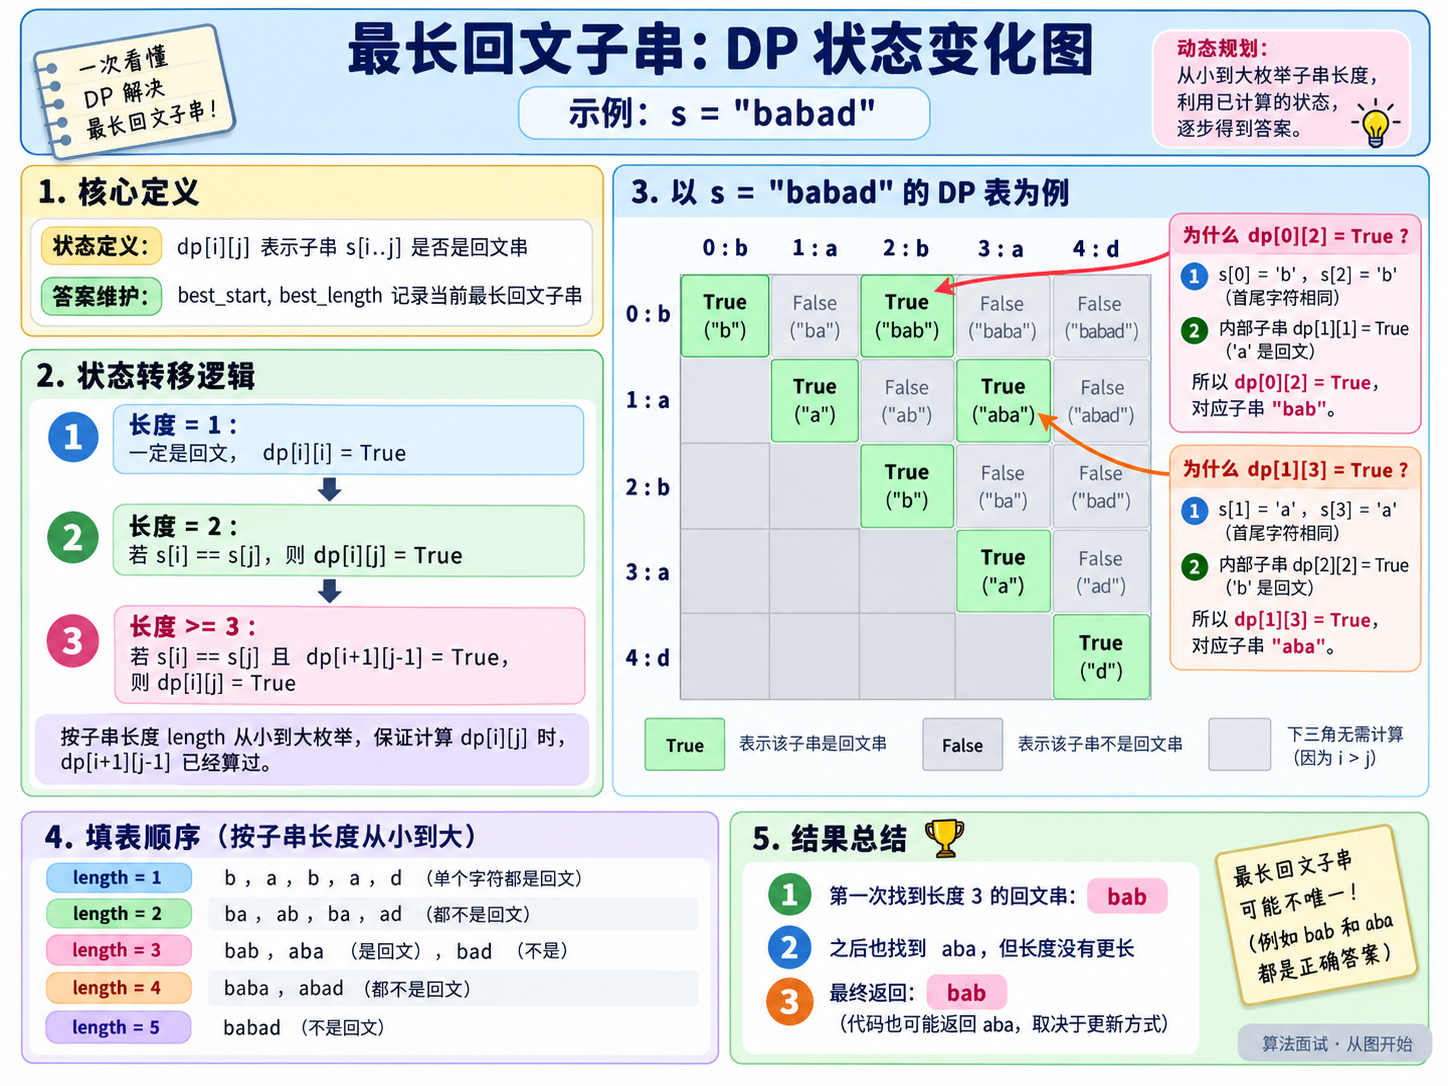

In [ ]:
class Solution:
    def longestPalindrome(self, s):
        n = len(s)
        dp = [[False] * n for _ in range(n)]
        best_len = 1
        best_lo, best_hi = 0, 1
        # lo起点索引，hi终点索引
        for length in range(1, n + 1):
            for lo in range(n - length + 1):
                hi = lo + length - 1
                if s[lo] == s[hi] and (length <= 2 or dp[lo + 1][hi - 1]):
                    dp[lo][hi] = True
                    if length > best_len:
                        best_len = length
                        best_lo, best_hi = lo, hi + 1
        return s[best_lo:best_hi]

print(Solution().longestPalindrome("babad"))  # bab 或 aba
print(Solution().longestPalindrome("cbbd"))   # bb

bab
bb


### 6.2 回文子串 · 647：复用真假状态，只改变答案的聚合方式
题目给定一个字符串 s，要求统计其中一共有多少个回文子串。

状态和转移与最长回文子串完全相同：`dp[i][j]` 仍表示整个 `s[i..j]` 是否回文。区别只在最终目标：

- 题 5 在所有 True 状态中保留长度最大的区间。
- 题 647 每发现一个 True 状态就把计数加 1。

不同位置即使字符内容相同，也对应不同的 `(i,j)`，所以应分别计数。例如 `"aaa"` 的回文区间包括三个长度 1、两个长度 2 和一个长度 3，共 6 个。

代码直接从长度 1 开始枚举，端点相等且内部回文时计数。这里的 `count += 1` 表示新发现了一个回文区间，与数组大小或字符下标无关。

时间、空间均为 O(n²)；若只求数量，也可用中心扩展把额外空间降为 O(1)。

In [ ]:
class Solution:
    def countSubstrings(self, s):
        n = len(s)
        dp = [[False] * n for _ in range(n)]
        count = 0
        # lo起点索引，hi终点索引
        for length in range(1, n + 1):
            for lo in range(n - length + 1):
                hi = lo + length - 1
                if s[lo] == s[hi] and (length <= 2 or dp[lo + 1][hi - 1]):
                    dp[lo][hi] = True
                    count += 1
        return count

print(Solution().countSubstrings("abc"))  # 3
print(Solution().countSubstrings("aaa"))  # 6

3
6


### 6.3 最长回文子序列 · 516：允许跳过字符后，状态从“是不是”变成“最长是多少”

题目给定一个字符串 `s`，要求找出其中**最长回文子序列的长度**。

这里最关键的是先区分“子串”和“子序列”：

* **子串**要求字符连续。
* **子序列**不要求连续，可以跳过中间的一些字符，但不能改变原有顺序。

例如：

```text
s = "bbbab"
```

可以选出：

```text
b b b b
```

它虽然不是连续子串，但仍然是一个回文子序列，因此答案为 `4`。


在最长回文子序列中，即使整个 `s[i..j]` 不是回文，我们仍然可以**跳过某些字符**，从里面选出一个最长回文子序列。

因此定义：

```text
dp[i][j] = 在区间 s[i..j] 中，最长回文子序列的长度
```

```

整个状态转移可以概括成：

```text
如果左右端点相等：
    把两个端点都留下
    dp[i][j] = dp[i+1][j-1] + 2

如果左右端点不相等：
    至少舍弃一个端点
    dp[i][j] = max(dp[i+1][j], dp[i][j-1])
```

边界也很简单：

```text
dp[i][i] = 1
```

因为任意单个字符本身就是长度为 `1` 的回文子序列。

这里还有一个很重要的理解：

> `dp[i][j]` 已经不是在判断整个区间本身是不是回文，而是在问：**这个区间里面，我最多能选出多长的回文子序列。**

所以最终答案不需要再额外遍历寻找最大值，直接就是：

```text
dp[0][n-1]
```

因为它表示整个字符串范围内的最长回文子序列长度。


时间复杂度：`O(n²)`。

空间复杂度：`O(n²)`。

另外，最长回文子序列还有一个经典等价关系：

```text
Longest Palindromic Subsequence(s)
=
Longest Common Subsequence(s, reversed(s))
```
也就是原字符串和它的逆序字符串做最长公共子序列。
不过对于这道题本身，使用区间 DP 更直观，因为它直接体现了核心决策：
```text
左右相等 → 两边都要
左右不同 → 舍弃一边
```

In [182]:
class Solution:
    def longestPalindromeSubseq(self, s: str) -> int:
        n = len(s)
        if n == 0:
            return 0

        dp = [[0] * n for _ in range(n)]
        for i in range(n):
            dp[i][i] = 1

        for length in range(2, n + 1):
            for i in range(n - length + 1):
                j = i + length - 1
                if s[i] == s[j]:
                    dp[i][j] = dp[i + 1][j - 1] + 2
                else:
                    dp[i][j] = max(dp[i + 1][j], dp[i][j - 1])
        return dp[0][n - 1]


print(Solution().longestPalindromeSubseq("bbbab"))  # 4
print(Solution().longestPalindromeSubseq("cbbd"))   # 2

4
2


## 附录 · 从题面到状态的动态规划总地图

六个模块不是按题目名称硬分，而是按“描述一个子问题需要哪些坐标”来分。先确定坐标，很多看似不同的题目就会落到同一种依赖结构中。

| 模块 | 状态坐标 | 看到什么信号 | 推导时最关键的问题 |
|---|---|---|---|
| M1 线性 DP | `dp[i]` | 一个进度轴、前缀或固定结尾 | 状态是“前 i 个全局最优”，还是“必须以 i 结尾”？ |
| M2 状态机 DP | `dp[i][state]` | 同一时刻有持有、空仓等互斥状态 | 前一状态经过什么动作才能到当前状态？ |
| M3 背包 DP | `dp[capacity]` | 选择物品达到容量、和或目标 | 每件物品能用几次？统计组合还是排列？ |
| M4 双序列 DP | `dp[i][j]` | 两个序列的处理进度可独立变化 | 上、左、左上分别表示哪种最后一步？ |
| M5 网格 DP | `dp[row][col]` | 坐标移动受限，或固定角描述局部形状 | 当前格有哪些前驱？应相加、取最值还是清零？ |
| M6 区间 DP | `dp[left][right]` | 同一序列两端收缩或区间切分 | 去左、去右、去两端，还是枚举切分点？ |

### 一套可以真正推导公式的五步法

1. **定义状态与答案位置**：用完整句子说清 `dp[...]` 覆盖的范围、是否必须选择当前位置，以及答案是某个状态还是所有状态的最值。
2. **枚举最后一次决策**：列出到达当前状态的所有互斥来源，再决定相加、取 `min`、取 `max` 或做布尔判断。
3. **赋予边界语义**：空前缀、容量 0、起点、单元素和不可达状态分别代表什么，初值就由这些含义决定。
4. **按照依赖安排遍历**：先算公式右侧，再算左侧；一维背包的正序／倒序、区间 DP 的长度顺序都来自这一原则。
5. **用最小样例检查并考虑压缩**：代入空输入、一个元素和两个元素，确认下标与答案位置；只在依赖关系允许时压缩空间。

### “加一”“加二”和“多开一格”分别在表达什么

| 写法 | 真正含义 | 典型例子 |
|---|---|---|
| 数组大小 `n+1` | 把长度 0、容量 0 或台阶 0 也建成状态 | 前缀 DP、背包、爬楼梯 |
| 转移结果 `+1` | 当前决策新贡献一个元素、一次操作或一格边长 | LIS、编辑距离、最大正方形 |
| 转移结果 `+2` | 当前决策同时加入左右两个元素 | 最长回文子序列 |
| 计数初值 `dp[0]=1` | 构造空目标有一种“什么都不选”的方案 | 背包计数、不同子序列、路径起点 |
| 状态保持 0 | 长度为 0、尚无方案，或当前状态不可达 | 空 LCS、障碍格、最大正方形中的 0 |

数组多开一格是在设计**坐标系**，转移中的 `+1/+2` 是在计算**当前决策的贡献**，初始化为 1 是在给**计数递推提供种子**。三者写法相似，但语义互不替代。

### 六模块题目索引

| 题号 | 题目 | 模块 | 一句话抓住状态与转移 |
|---:|---|:---:|---|
| 70 | 爬楼梯 | M1 | 到第 i 阶的方法数；由前两个位置相加 |
| 746 | 最小花费爬楼梯 | M1 | 到位置 i 已付的最小花费；离开前驱时付费 |
| 198 | 打家劫舍 | M1 | 前 i 家的全局最优；偷当前就跳过前一家 |
| 213 | 打家劫舍 II | M1 | 环拆成两段互斥的线性问题 |
| 53 | 最大子数组 | M1 | 必须以 i 结尾；续接前缀或从当前重启 |
| 118 | 杨辉三角 | M1 | 当前数来自上一行左右两个父节点 |
| 300 | 最长递增子序列 | M1 | 以 i 结尾；枚举可接到 i 的前驱 |
| 32 | 最长有效括号 | M1 | 以 i 结尾的有效长度；按匹配位置回接 |
| 152 | 乘积最大子数组 | M1/M2 | 固定结尾；负数会交换最大与最小角色 |
| 121 | 股票：一次交易 | M2 | 持有与空仓；买入只能从初始现金出发 |
| 122 | 股票：多次交易 | M2 | 持有与空仓循环转移；买入可携带历史利润 |
| 309 | 股票：冷冻期 | M2 | 为限制买入来源，拆分刚卖出与可买入空仓 |
| 714 | 股票：手续费 | M2 | 状态图不变，在一次完成交易的边上扣费 |
| 416 | 分割等和子集 | M3 | 目标减半；0/1 可达性，容量倒序 |
| 494 | 目标和 | M3 | 转成选择正号集合；0/1 计数 |
| 322 | 零钱兑换 | M3 | 完全背包；前驱最少硬币数加 1 |
| 518 | 零钱兑换 II | M3 | 外层枚举硬币，统计无序组合 |
| 279 | 完全平方数 | M3 | 与零钱兑换同构，物品变成平方数 |
| 139 | 单词拆分 | M3 | 前缀可达；枚举最后一个单词的起点 |
| 377 | 组合总和 IV | M3 | 按最后一个数分类，统计有序排列 |
| 1143 | 最长公共子序列 | M4 | 两个前缀全局最优；匹配走左上，否则取上／左 |
| 718 | 最长重复子数组 | M4 | 固定两个结尾；匹配时续接左上，不匹配归零 |
| 72 | 编辑距离 | M4 | 删除、插入、替换分别对应上、左、左上 |
| 583 | 两字符串删除 | M4 | 只允许删除；也可理解为尽量保留 LCS |
| 115 | 不同的子序列 | M4 | 来源字符用或不用；匹配时两类方案相加 |
| 62 | 不同路径 | M5 | 到达当前格的路径数等于上方加左方 |
| 63 | 不同路径 II | M5 | 依赖不变，障碍把当前状态清零 |
| 64 | 最小路径和 | M5 | 前驱取较小值，再加入当前格代价 |
| 120 | 三角形最小路径和 | M5 | 反向定义后，从两个孩子中选较小者 |
| 221 | 最大正方形 | M5 | 固定右下角；上、左、左上的短板加 1 |
| 5 | 最长回文子串 | M6 | 精确区间真假；端点相等且内部回文 |
| 647 | 回文子串 | M6 | 复用回文真假状态，统计所有 True 区间 |
| 516 | 最长回文子序列 | M6 | 区间最优；相等加 2，不等跳过一端 |

复习时不必先背公式。先遮住代码，尝试说出状态的完整含义、答案位置、最后一次决策和边界语义；这四件事能够自洽，公式通常会自然出现。